---
title: Evaluating Machine Learning Models
author: Mark Fuge
date: 'September 19 2025'
format:
    html:
        code-fold: true
---

In the prior chapter, we covered how different loss functions and regularization terms affected a linear model, in terms of the model's qualitative performance and its effect on the training score. However, as we saw, the training score can be a misleading performance indicator. How might we judge the model's performance more rigorously? This chapter addresses this by reviewing the why and how of performing Cross Validation, and also what this means regarding optimizing the hyperparameters of a model.


**Learning Objectives**

By the end of this chapter, you should be able to:

1. Explain why training error is an optimistic estimate of performance, and use hold-out and $k$-fold cross-validation to estimate out-of-sample error instead.
2. Choose a cross-validation strategy (shuffled, stratified, grouped, time-ordered) that matches how the model will be used, and recognize the leakage each one prevents.
3. Select hyperparameters such as the regularization strength and the polynomial degree from validation curves and cross-validation grids.
4. Use grid search and randomized search over a pipeline, and state when each is preferable.
5. Describe Bayesian optimization as model-based search with an acquisition function, and say when it pays off.
6. Explain the curse of dimensionality and its consequences for search and for distance-based methods.

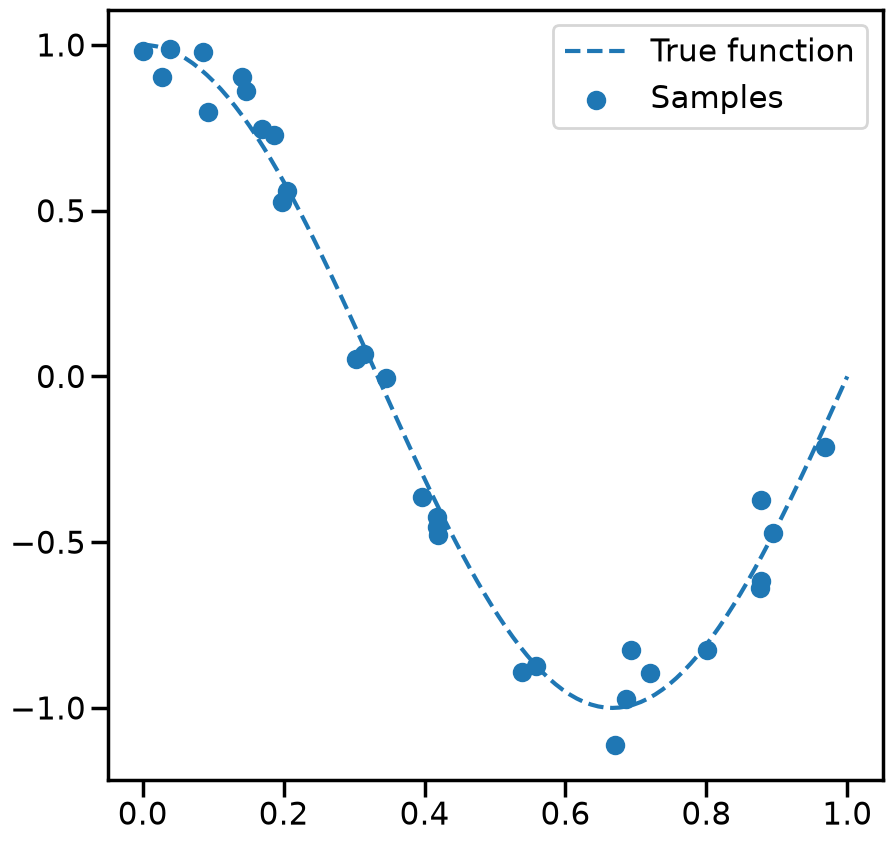

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
import seaborn as sns
sns.set_context('poster')
pal = sns.color_palette("Paired")
cmap = sns.blend_palette(pal,as_cmap=True)
np.random.seed(1)

# Number of data points
n_samples = 30

# True Function we want to estimate
true_fun = lambda X: np.cos(1.5 * np.pi * X)

# Noisy Samples from the true function
X_cos = np.sort(np.random.rand(n_samples))
y_cos = true_fun(X_cos) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(10,10))
# Plot the true function:
X_plot = np.linspace(0, 1, 100)
plt.plot(X_plot, true_fun(X_plot), '--',label="True function")
# Plot the data samples
plt.scatter(X_cos, y_cos, label="Samples")
plt.legend(loc="best")
plt.show()

## Getting an Unbiased Estimate of Out-of-Sample Performance

When we train a machine learning model, we are typically interested in how well the model will perform on data it has not seen before. This is often referred to as the model's generalization performance. However, if we evaluate the model's performance on the same data it was trained on, we may get an overly optimistic estimate of its true performance. This is because the model may have simply memorized the training data, rather than learning the underlying patterns. Put another way, assessing the model on data it was trained on does not give us an accurate picture of performance because the training loss is not an *unbiased* estimate of the model's out-of-sample performance, where *out-of-sample* here refers to new data I haven't seen yet. So how do we properly obtain (*i.e.*, in an unbiased way) an estimate of the model's out-of-sample performance? One popular way to assess this is through [Cross Validation](https://en.wikipedia.org/wiki/Cross-validation_(statistics)), where we attempt to split the given data into two sets -- a training set and a testing set -- where the testing set should come from a distribution similar to what we would expect to see in the real-world when we deploy the model. A simple way to do this is just to select points at random:

In [3]:
#| code-fold: false
# Now let's split the data into training and test data:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
     X_cos, y_cos, test_size=0.2, random_state=0)

Let's take a look at what the above has actually done.

X_train
 [8.78142503e-01 3.02332573e-01 4.19194514e-01 6.92322616e-01
 1.40386939e-01 4.17304802e-01 1.86260211e-01 3.96767474e-01
 7.20324493e-01 6.70467510e-01 2.73875932e-02 9.68261576e-01
 1.46755891e-01 9.23385948e-02 5.38816734e-01 5.58689828e-01
 1.98101489e-01 1.69830420e-01 8.76389152e-01 8.50442114e-02
 1.14374817e-04 6.85219500e-01 4.17022005e-01 3.13424178e-01] 

X_test
 [0.03905478 0.89460666 0.34556073 0.20445225 0.87811744 0.80074457] 

y_train
 [-0.37395132  0.05199163 -0.47818202 -0.82672018  0.90350849 -0.45417721
  0.72898424 -0.36366041 -0.89399733 -1.11157064  0.90389734 -0.21270638
  0.86040424  0.79675107 -0.89105816 -0.87458209  0.52662674  0.74673588
 -0.63887828  0.97904574  0.98275703 -0.97273902 -0.42390528  0.0668933 ] 

y_test
 [ 0.98733352 -0.47140604 -0.00455281  0.55839434 -0.61801179 -0.82613321] 



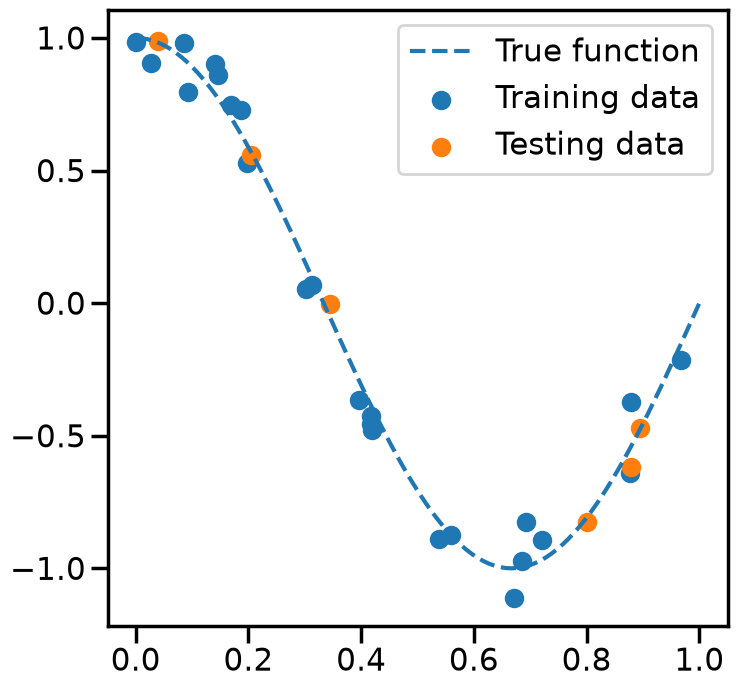

In [4]:
print('X_train\n',X_train,'\n')
print('X_test\n',X_test,'\n')
print('y_train\n',y_train,'\n')
print('y_test\n',y_test,'\n')

plt.figure(figsize=(8,8))
plt.plot(X_plot, true_fun(X_plot), '--',label="True function")
# plot the training and testing points in colors
plt.scatter(X_train,y_train, label="Training data")
plt.scatter(X_test,y_test, label="Testing data")
plt.legend(loc="best")
plt.show()

We can now plot or track the error across both the training and testing data to see how the different models compare:

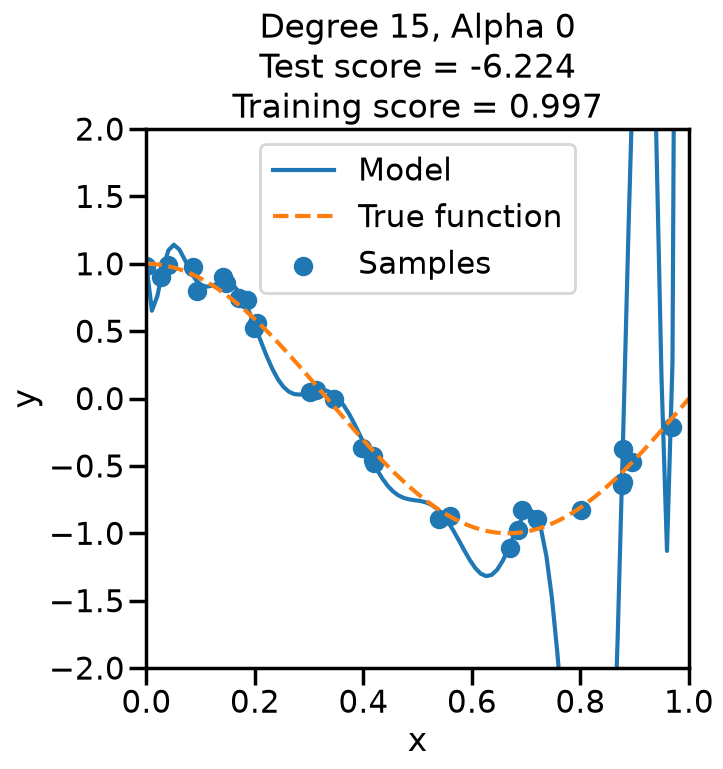

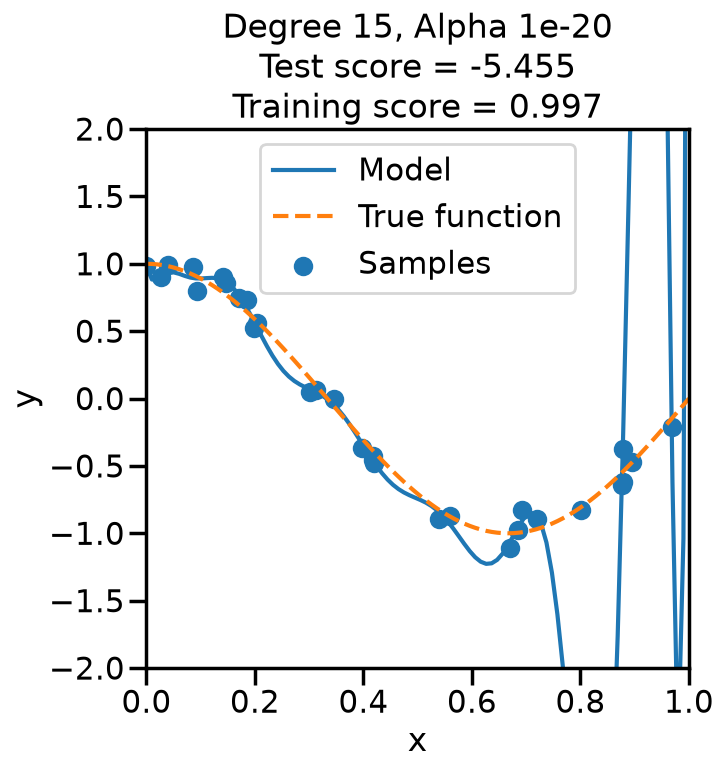

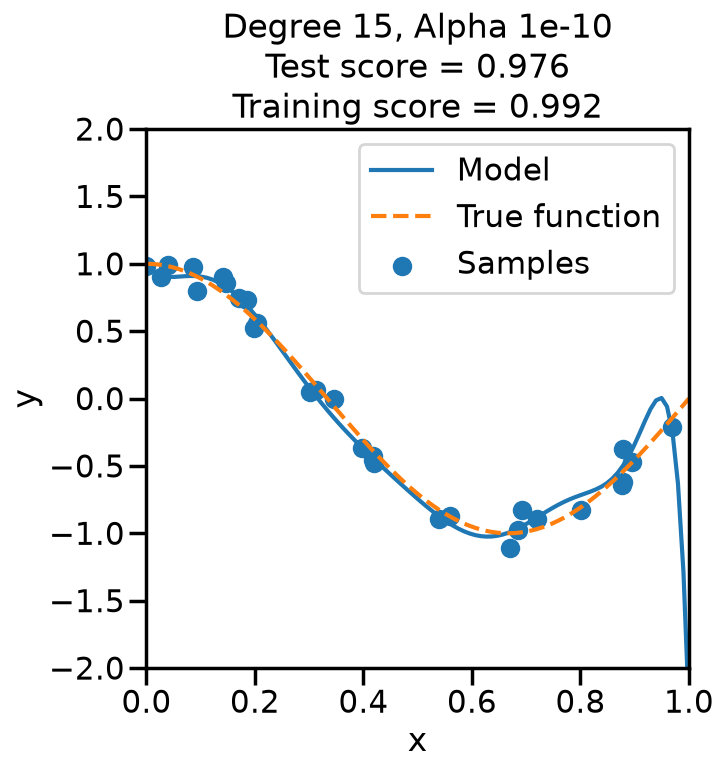

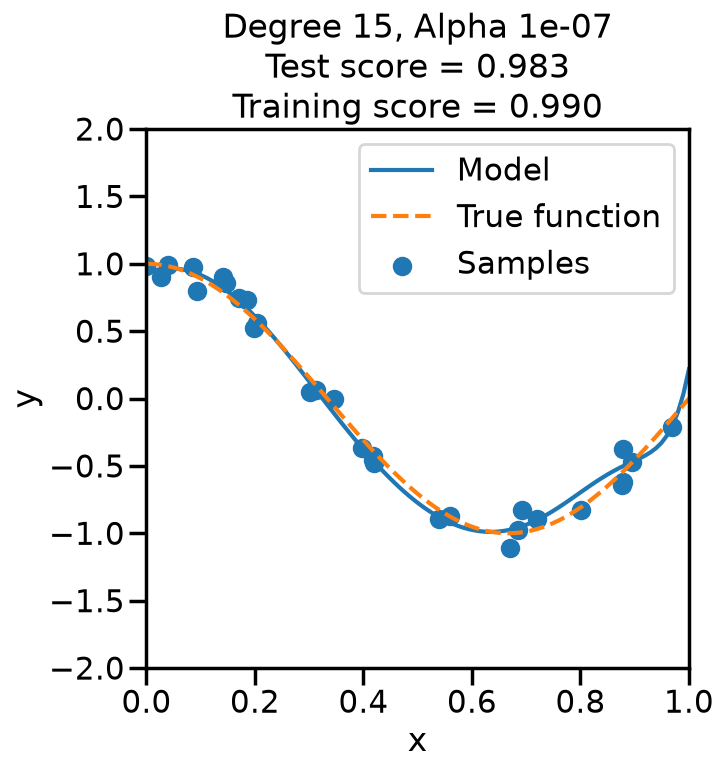

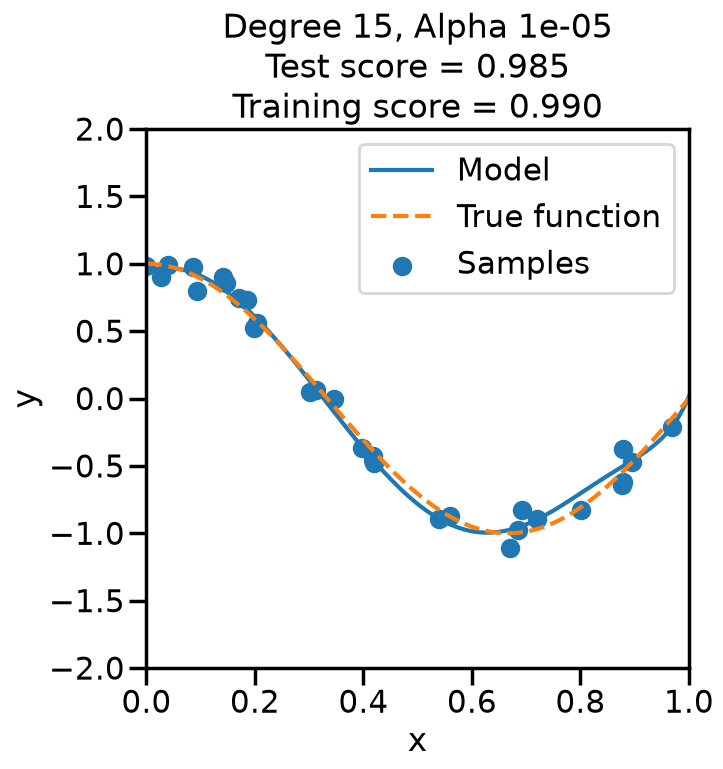

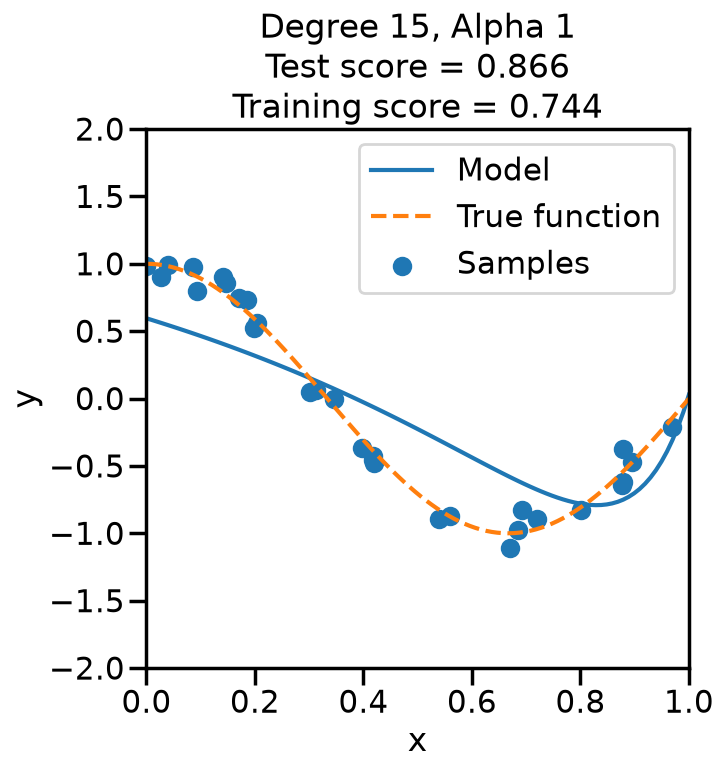

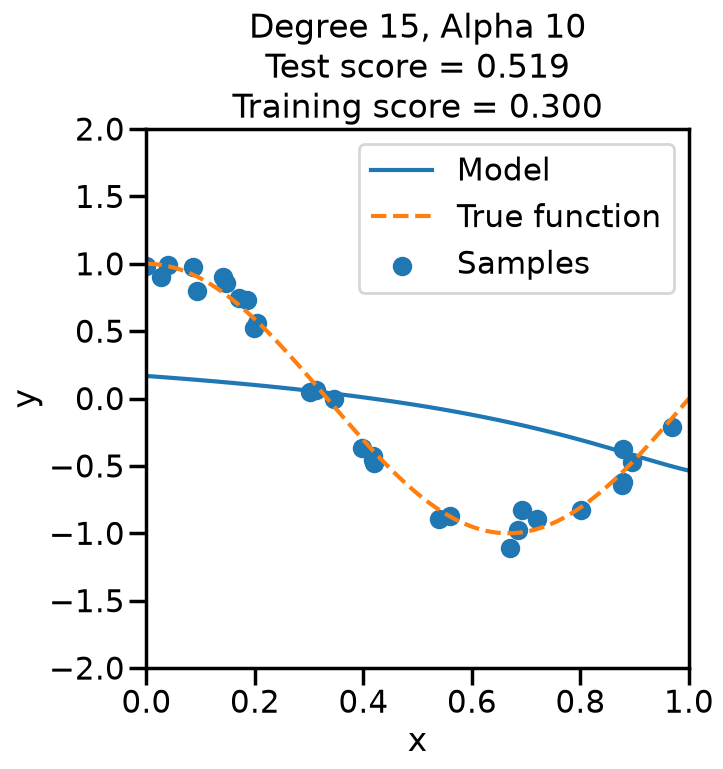

In [5]:
alphas = [0, 1e-20, 1e-10, 1e-7, 1e-5, 1,10]
d=15
for a in alphas:
    plt.figure(figsize=(7, 7))
    #plt.setp(ax, xticks=(), yticks=())
    polynomial_features = PolynomialFeatures(degree=d,
                                             include_bias=False)
    linear_regression = LinearRegression()
    linear_regression = Ridge(alpha=a)
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    #pipeline.fit(X[:, np.newaxis], y)
    pipeline.fit(X_train[:, np.newaxis], y_train)
    # Evaluate the models using crossvalidation
    #scores = cross_validation.cross_val_score(pipeline,
    #    X[:, np.newaxis], y, scoring="mean_squared_error", cv=10)
    
    testing_score = pipeline.score(X_test[:, np.newaxis],y_test)
    training_score = pipeline.score(X_train[:, np.newaxis],y_train)

    X_plot = np.linspace(0, 1, 100)
    plt.plot(X_plot, pipeline.predict(X_plot[:, np.newaxis]), label="Model")
    plt.plot(X_plot, true_fun(X_plot), '--',label="True function")
    plt.scatter(X_cos, y_cos, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    
    plt.title("Degree {}, Alpha {}\nTest score = {:.3f}\nTraining score = {:.3f}".format(
        d, a, testing_score,training_score))
    plt.show()

We can see from the above behavior that while the training score prefers the increasingly more complex models, the test score tells us more accurately how the model would perform under new data that it hasn't seen yet, and that we can use this information to actually assess which model to choose.

## Choosing a Cross-Validation Strategy

The split above is the simplest kind of cross-validation: shuffle the rows, select some that we will hold out for test data, and then fit the model on the remaining training data. In principle, this sounds reasonable, but is this always the correct approach? Should we be selecting our test data a different way? The key to answering this question is to ask yourself whether you are selecting test data that is truly an *unbiased* estimate of the *out-of-sample* error. Let's unpack what this means. For the data to represent something which is out of sample, this means the data that I'm selecting for testing needs to represent new samples of data that I am likely to see in reality. To make this a little less abstract we can look at three types of situations that commonly occur in cross validation where just randomly splitting the data as we did above would cause problems:

1. **Stratification:** Consider cases where the data suffers from severe class imbalance -- for example let's say I have 1000 samples of engine performance but only five of those samples contain engine faults. Faulty data will not be heavily represented in the data overall. What is likely to happen if I just sampled this data randomly is that by chance I may get all of the faulty data in my training set and none of it in my test set. If this happens my test set will not look like my actual out of sample error in the sense that it will only be testing the model's ability to predict non-faulty or normal engine data and I will not get an accurate out of sample estimate for its true performance in real world conditions. The solution here would be to maintain the same ratio of normal to faulty data points across both the training and testing sets. This is referred to in cross validation as *stratification*. In libraries that implement cross validation, or if you were doing this manually yourself, you would first need to separate out the different classes or bands or regimes in which you expect your data to vary significantly and then sample the data in proportion to these bands in a similar way across both the training and testing splits. We will see examples below in `sklearn` of `StratifiedKFold` that do this, but the idea is simple enough you could implement it yourself.
2. **Grouping**: Often we may have data that is specific to individual parts or patients or systems where we would like to train a model on them, but then in deployment in the real world we would have to test on new parts or patients that we have never seen previously. For example, you can imagine a case where I have ten turbine blades, and for each I have time series data on their fatigue and vibration performance. I might wish to build a model that can predict their remaining useful life so that I could predict a servicing envelope. It would be tempting to just take the entire set of data for all blades and randomly sample different time points and build a predictive model that tests on other time points for all blades. However, this is not a realistic situation that I would encounter in the real world, since this would imply that I have the ability to look at random time histories of every part that I would be required to test and likely this will not be the case because I will be asked to predict new turbine blades that I never trained on. Rather, I would have, say, only eight of the turbine blades as a group that I could train on, and then my test data would look like two completely new turbine blades that I never trained on; turbine blades for whom I have zero history or knowledge. In cross validation this is referred to as *grouping* since I am essentially taking a subset of my time series data and purposefully grouping them by a part number in this case and testing on a completely new set of groups, that is new part numbers. In `sklearn` the `GroupKFold` is an example of this.
3. **Time Series Splitting**: Lastly, I might be in a situation where I need to make predictions about the future, say for our turbine blade remaining useful life estimate above or perhaps for some dynamical system. In these cases it does not make sense to take a single time series and split different points in time into training and testing since then I would be training on points that could occur in the future and using them to predict test points that might occur in the past. You can imagine that it would be far easier to predict the future if I already got an opportunity to see another point in the further future! As a result for anything in which we need to do forecasting in either space or time where we expect that we will not be able to rely upon measurements of those future quantities at deployment time, we need to train and test our model under similar circumstances. What this looks like is taking a set of time series data and then picking randomly some split point in time wherein I can train on any data in the past but only test on data in the future. This then mirrors my actual out-of-sample error that my model is likely to incur. 

Notice that these are not mutually exclusive: a dataset can be grouped *and* ordered in time, and you may have to build the splitter yourself (see below exercises). The same logic also applies to any preprocessing you fit: a scaler or a PCA fit on all rows before splitting has already looked at the test data. Putting preprocessing inside a `Pipeline`, as this chapter does, keeps the preprocessing fit only on the training fold. For further details on common Cross Validation strategies, you can read the [scikit-learn User Guide page on cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html). 

To see what each splitter actually does, let us give our thirty points three plausible attributes: they were measured in time order (so the sorted $x$ doubles as a clock), each third of the $x$ range came from a different test rig, and each point has a class label (positive or negative $y$). The figure shows which rows each strategy puts into the test fold (dark) and the training fold (light) for four folds.

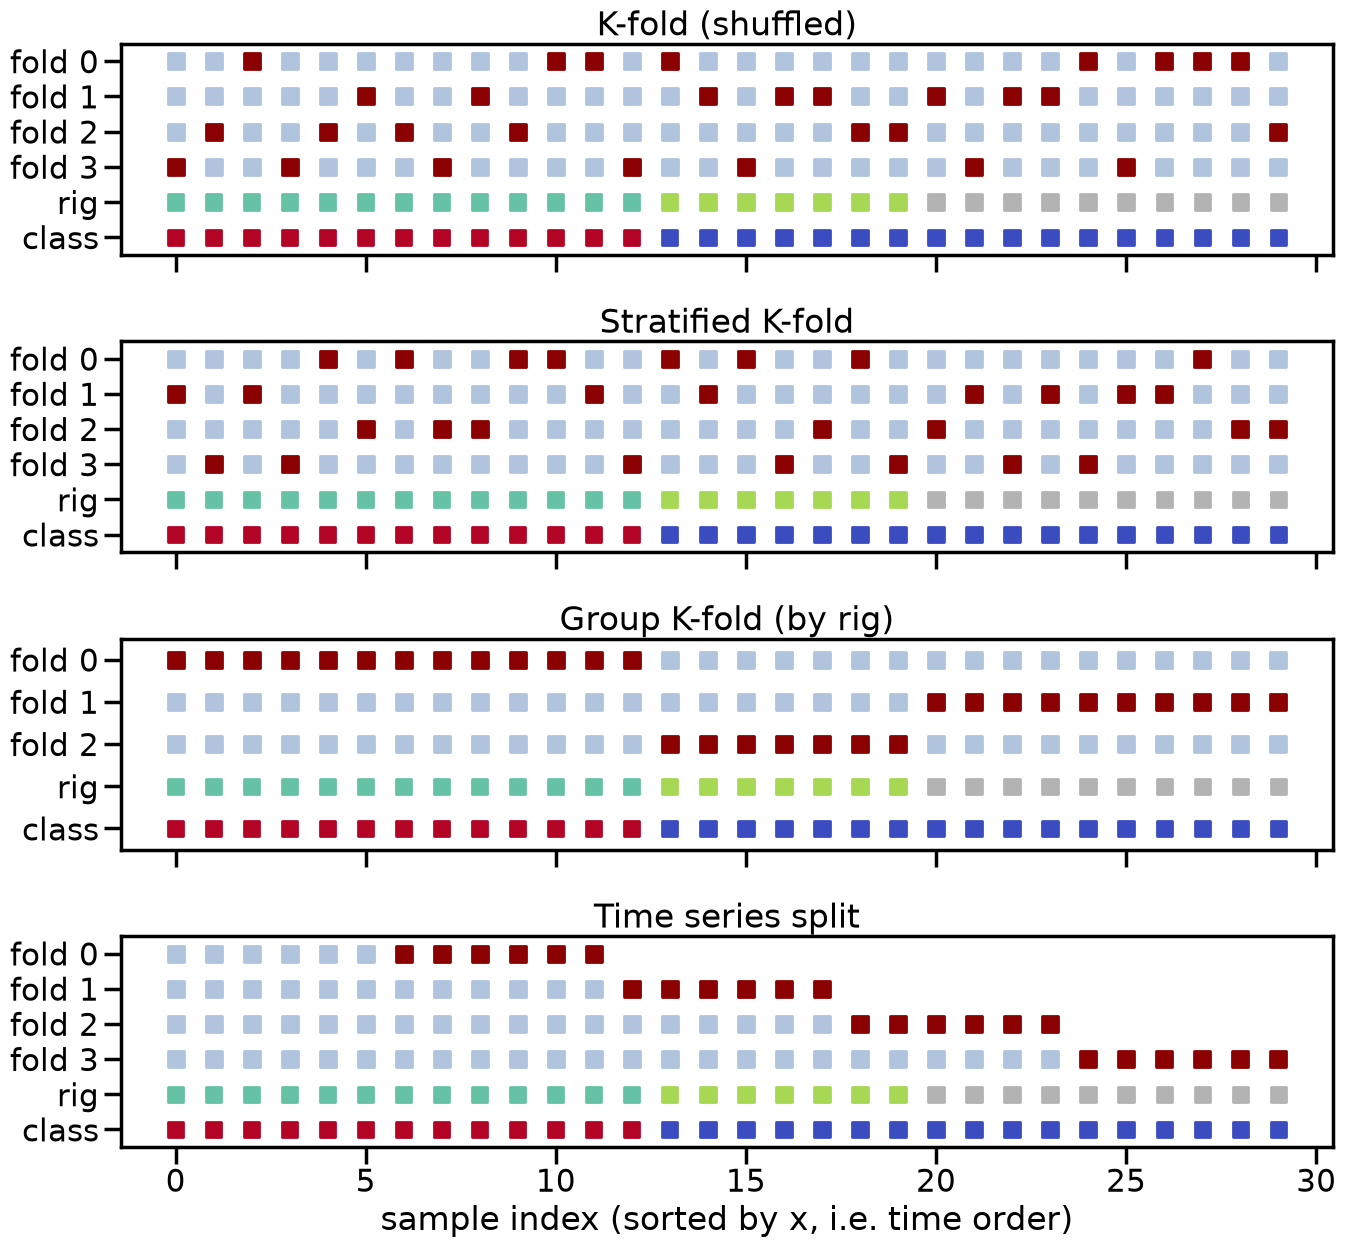

In [6]:

#| echo: false
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, TimeSeriesSplit

# Three attributes for the 30 points: time order (they are already sorted by x), rig, and class
rig_of_point = np.digitize(X_cos, [1/3, 2/3])          # 0, 1, 2: which of three rigs measured the point
class_of_point = (y_cos > 0).astype(int)               # 1 if y is positive, else 0
sample_index = np.arange(len(X_cos))

strategies = {
    "K-fold (shuffled)": (KFold(n_splits=4, shuffle=True, random_state=0), {}),
    "Stratified K-fold": (StratifiedKFold(n_splits=4, shuffle=True, random_state=0), {"y": class_of_point}),
    "Group K-fold (by rig)": (GroupKFold(n_splits=3), {"groups": rig_of_point}),
    "Time series split": (TimeSeriesSplit(n_splits=4), {}),
}

fig, axes = plt.subplots(len(strategies), 1, figsize=(14, 13), sharex=True)
for ax, (name, (splitter, kwargs)) in zip(axes, strategies.items()):
    for fold, (train_idx, test_idx) in enumerate(splitter.split(X_cos[:, np.newaxis], **kwargs)):
        ax.scatter(train_idx, np.full(len(train_idx), fold), marker='s', s=120, color='lightsteelblue')
        ax.scatter(test_idx, np.full(len(test_idx), fold), marker='s', s=120, color='darkred')
    n_folds = splitter.get_n_splits()
    ax.scatter(sample_index, np.full(len(X_cos), n_folds), marker='s', s=120,
               c=rig_of_point, cmap='Set2', vmin=0, vmax=2)
    ax.scatter(sample_index, np.full(len(X_cos), n_folds + 1), marker='s', s=120,
               c=class_of_point, cmap='coolwarm', vmin=0, vmax=1)
    ax.set_yticks(list(range(n_folds)) + [n_folds, n_folds + 1])
    ax.set_yticklabels([f"fold {k}" for k in range(n_folds)] + ["rig", "class"])
    ax.set_ylim(n_folds + 1.5, -0.5)
    ax.set_title(name)
axes[-1].set_xlabel("sample index (sorted by x, i.e. time order)")
plt.tight_layout()
plt.show()


Dark squares are test rows and the two extra rows show each point's rig and class. Shuffled K-fold sprinkles test points everywhere. Stratified K-fold looks similar but guarantees that both classes appear in every test fold in similar proportion. Group K-fold holds out one entire rig at a time, so every test fold asks the model to predict a region of $x$ it has never seen. The time series split only ever tests on points that come after all the training points.

While this example was a little bit contrived, we can see that the different cross validation strategies give very different final MSE numbers. Here is the 15-degree ridge polynomial from above for different cross validation strategies. In the figure, the left column shows which rows each fold holds out (coloured squares) and the right column shows the model fitted on each fold's training rows, in that fold's colour, together with the test points it is scored on:

                strategy   mean test MSE
       K-fold (shuffled)        0.062
   Group K-fold (by rig)        7.352
       Time series split        1.192


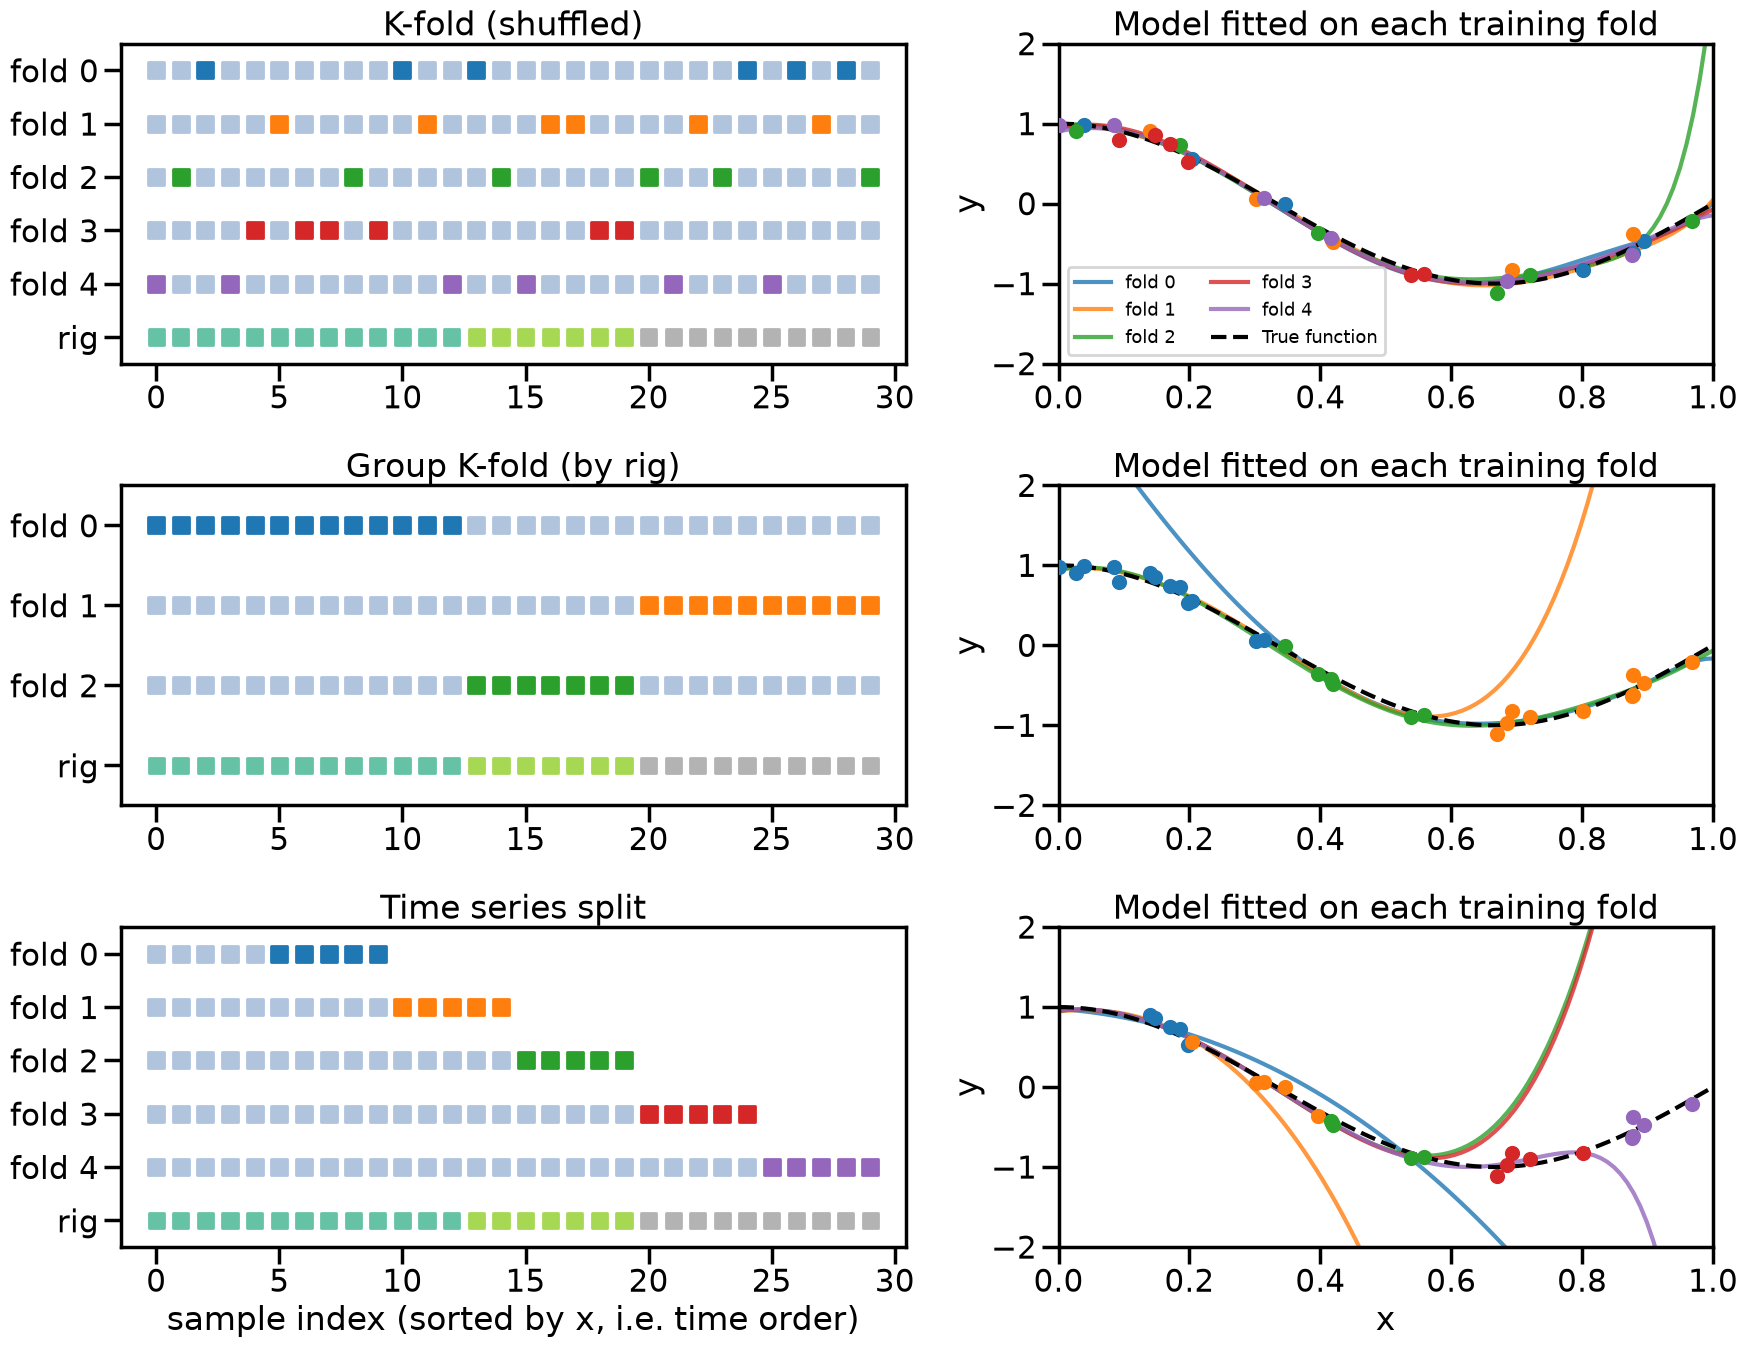

In [7]:
from sklearn.model_selection import cross_val_score

cv_demo_pipeline = Pipeline([("polynomial_features", PolynomialFeatures(degree=15, include_bias=False)),
                             ("linear_regression", Ridge(alpha=1e-5))])

cv_comparison = {
    "K-fold (shuffled)": (KFold(n_splits=5, shuffle=True, random_state=0), {}),
    "Group K-fold (by rig)": (GroupKFold(n_splits=3), {"groups": rig_of_point}),
    "Time series split": (TimeSeriesSplit(n_splits=5), {}),
}
print(f"{'strategy':>24s}   mean test MSE")
for name, (splitter, kwargs) in cv_comparison.items():
    fold_mse = -cross_val_score(cv_demo_pipeline, X_cos[:, np.newaxis], y_cos,
                                scoring="neg_mean_squared_error", cv=splitter, **kwargs)
    print(f"{name:>24s}   {fold_mse.mean():10.3f}")

# For each strategy: which rows each fold holds out (left) and the model fitted on each fold's
# training rows, drawn in that fold's colour together with the test points it is scored on (right)
X_plot = np.linspace(0, 1, 100)
fig, axes = plt.subplots(len(cv_comparison), 2, figsize=(18, 14), gridspec_kw={"width_ratios": [1.2, 1]})
for (ax_folds, ax_fit), (name, (splitter, kwargs)) in zip(axes, cv_comparison.items()):
    n_folds = splitter.get_n_splits()
    for fold, (train_idx, test_idx) in enumerate(splitter.split(X_cos[:, np.newaxis], **kwargs)):
        ax_folds.scatter(train_idx, np.full(len(train_idx), fold), marker='s', s=120, color='lightsteelblue')
        ax_folds.scatter(test_idx, np.full(len(test_idx), fold), marker='s', s=120, color=f"C{fold}")

        cv_demo_pipeline.fit(X_cos[train_idx][:, np.newaxis], y_cos[train_idx])
        ax_fit.plot(X_plot, cv_demo_pipeline.predict(X_plot[:, np.newaxis]), color=f"C{fold}", alpha=0.8, label=f"fold {fold}")
        ax_fit.scatter(X_cos[test_idx], y_cos[test_idx], color=f"C{fold}", s=80, zorder=3)
    ax_folds.scatter(sample_index, np.full(len(X_cos), n_folds), marker='s', s=120,
                     c=rig_of_point, cmap='Set2', vmin=0, vmax=2)
    ax_folds.set_yticks(list(range(n_folds)) + [n_folds])
    ax_folds.set_yticklabels([f"fold {k}" for k in range(n_folds)] + ["rig"])
    ax_folds.set_ylim(n_folds + 0.5, -0.5)
    ax_folds.set_title(name)

    ax_fit.plot(X_plot, true_fun(X_plot), 'k--', label="True function")
    ax_fit.set_xlim((0, 1))
    ax_fit.set_ylim((-2, 2))
    ax_fit.set_ylabel("y")
    ax_fit.set_title("Model fitted on each training fold")
axes[-1, 0].set_xlabel("sample index (sorted by x, i.e. time order)")
axes[-1, 1].set_xlabel("x")
axes[0, 1].legend(loc="lower left", fontsize=13, ncol=2)
plt.tight_layout()
plt.show()


Part of the reason the scores are so different is that in the grouped and time series case, the model has to extrapolate in ways that are more difficult than what naive shuffle splitting is asking the model to do. But which of these is the "right" cross validation approach? This is where you need to use your intuition and logic for how you plan to deploy the trained model in practice. You will have to understand what it means to have a correct out of sample estimate of your error and then combine procedures to construct the cross validation appropriately. This is something where leveraging your domain knowledge and understanding of how and where data will be available in practice compared to training will come in handy.

## Finding the Optimal Hyper-parameters

Now that we have introduced the usage of hyper-parameters and cross-validation, a natural question arises: How do we choose the hyper-parameters? There are many ways to do this, and this section will describe the most common and basic ones, while leaving more advanced techniques (like Implicit Differentiation) for later. Specifically, this section will:
1. Define the concepts of Grid and Random Hyper-parameter search.
2. Use Grid and Random search to optimize hyper-parameters of a model.
2. Distinguish when Randomized Search is much better than grid search.
3. Describe how Global Optimization procedures such as Bayesian Optimization work.
4. Recognize why none of those at all work in High Dimensions and describe the "Curse of Dimensionality"

In future chapters once we cover more advanced derivative methods, we can discuss how to use tools like Implicit Differentiation to directly compute the gradient of the cross-validation score with respect to hyper-parameters, and then use this gradient to optimize the hyper-parameters using standard gradient-based optimization methods. However, for now, let's focus on more basic derivative-free methods, since they are more widely used and easier to understand.

Let's start by returning to our Polynomial example, and this time focus on finding the best combination of degree and penalty weight for a linear model.

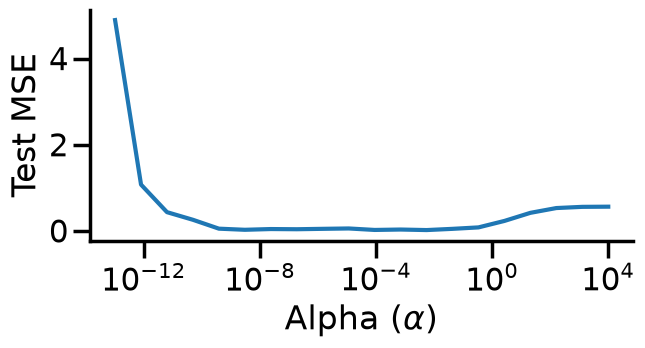

In [8]:
from sklearn import model_selection

# Let's plot the behavior of a fixed degree polynomial
degree = 15
# (i.e., f(x) = w_1*x + w_2*x^2 + ... + w_15*x^15)
# but where we change alpha.
alphas_1d = np.logspace(start=-13,stop=4,num=20)
polynomial_features = PolynomialFeatures(degree=degree,
                                         include_bias=False)
scores_1d = []
for a in alphas_1d:
    linear_regression = Ridge(alpha=a)
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    cv_scores = model_selection.cross_val_score(pipeline,
        X_cos[:,np.newaxis], y_cos, scoring="neg_mean_squared_error", cv=20)
    scores_1d.append(cv_scores)

scores_1d = np.array(scores_1d)

plt.figure(figsize=(7,3))
plt.semilogx(alphas_1d, -np.mean(scores_1d, axis=1), '-')
plt.ylabel('Test MSE')
plt.xlabel('Alpha ($\\alpha$)')
sns.despine()
plt.show()

## What if we have more than one variable?
Let's look at both polynomial degree and regularization weight

In [9]:
scores = []
alphas = np.logspace(start=-13, # Start at 1e-13
                     stop=4,    # Stop at 1e4
                     num=40)    # Split that into 40 pieces
degrees = range(1,16) # This will only go to 15, due to how range works

scores = np.zeros(shape=(len(degrees), # i.e., 15
                         len(alphas))) # i.e., 20

for i, degree in enumerate(degrees): # For each degree
    polynomial_features = PolynomialFeatures(degree=degree,
                                             include_bias=False)
    
    for j,a in enumerate(alphas):    # For each alpha
        linear_regression = Ridge(alpha=a)
        pipeline = Pipeline([("polynomial_features", polynomial_features),
                             ("linear_regression", linear_regression)])
        cv_scores = model_selection.cross_val_score(pipeline,
            X_cos[:,np.newaxis], y_cos, scoring="neg_mean_squared_error", cv=20)
        scores[i][j] = -np.mean(cv_scores)


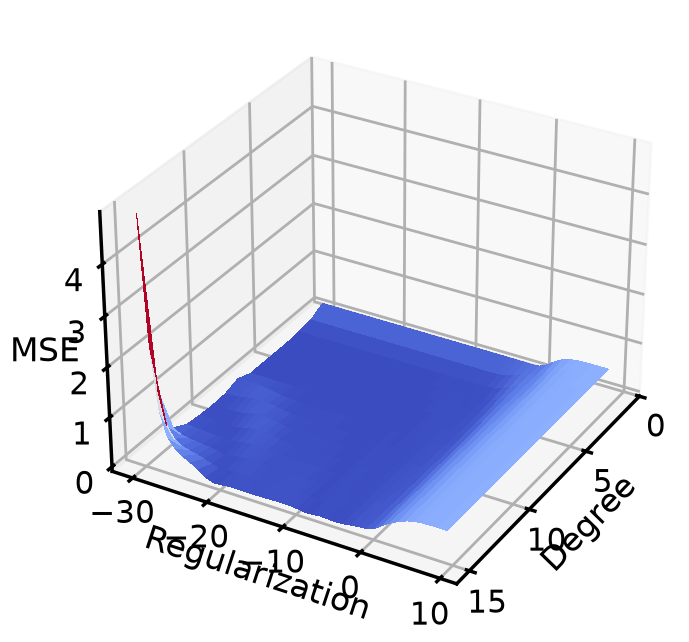

In [10]:
fig = plt.figure(figsize=(10,7))
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
ax = fig.add_subplot(111, projection='3d')

Xs, Ys = np.meshgrid(range(len(degrees)), range(len(alphas)))
zs = np.array([scores[i,j] for i,j in zip(np.ravel(Xs), np.ravel(Ys))])
Zs = zs.reshape(Xs.shape)

Xs, Ys = np.meshgrid(degrees, np.log(alphas))

ax.plot_surface(Xs, Ys, Zs, rstride=1, cstride=1, cmap=cm.coolwarm,
    linewidth=0, antialiased=False)

# Label the Axes
ax.set_xlabel('Degree')
ax.set_ylabel('Regularization')
ax.set_zlabel('MSE')

# Rotate the image
ax.view_init(30, # larger # goes "higher"
             30) # larger # "circles around"
plt.tight_layout()
plt.show()

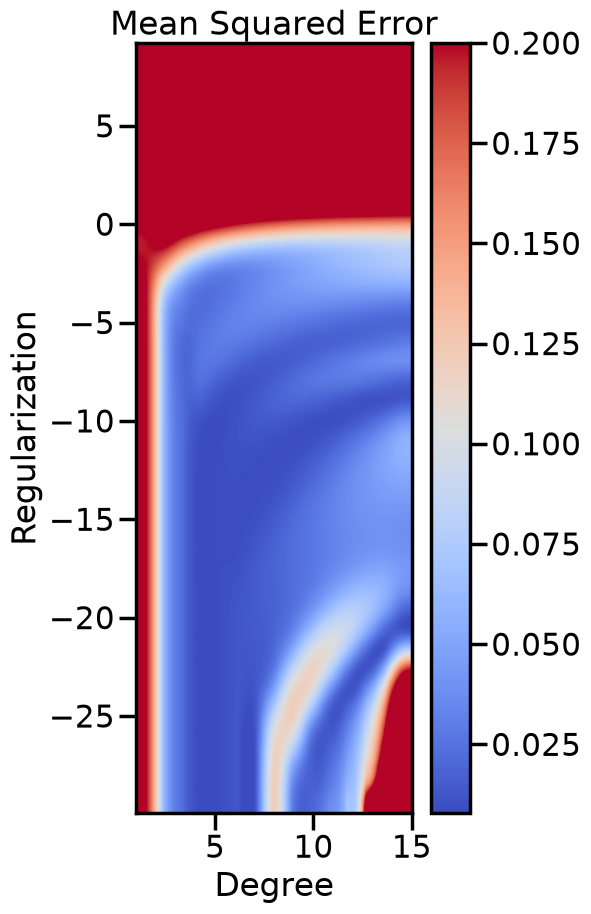

In [11]:
plt.figure(figsize=(5,10))
plt.imshow(Zs,
           cmap=cm.coolwarm, # Allows you to set the color
           vmin=Zs.min(), vmax=0.2, # The min and max Z-Values (for coloring purposes)
           extent=[Xs.min(), Xs.max(),   # How far on X-Axis you want to plot
                   Ys.min(), Ys.max()],  # How far on Y-Axis
           interpolation='spline16',      # How do you want to interpolate values between data?
           origin='lower')
plt.title('Mean Squared Error')
plt.xlabel('Degree')
plt.ylabel('Regularization')
plt.colorbar()

## Optimization
At the end of the day, all this is doing is optimization/search over different parameters. How should we go about automating this? The most common and easy to implement method is Grid Search, which will work OK for us when the number of possible hyper-parameters are small and have equal effect on the model performance:

In [12]:
print('parameters we could change:')
for k in pipeline.get_params():
    print(" ",k)

parameters we could change:
  memory
  steps
  transform_input
  verbose
  polynomial_features
  linear_regression
  polynomial_features__degree
  polynomial_features__include_bias
  polynomial_features__interaction_only
  polynomial_features__order
  linear_regression__alpha
  linear_regression__copy_X
  linear_regression__fit_intercept
  linear_regression__max_iter
  linear_regression__positive
  linear_regression__random_state
  linear_regression__solver
  linear_regression__tol


In [13]:
from sklearn.model_selection import GridSearchCV
parameters = {'polynomial_features__degree': list(range(1,16)), # 15 possible
              'linear_regression__alpha': np.logspace(start=-13,stop=4,num=10),
              'polynomial_features__include_bias':[True, False]}

In [14]:
# How do we want to do cross-validation?
from sklearn import model_selection
num_data_points = len(y_cos)

# 4-fold CV
kfold_cv = model_selection.KFold(n_splits = 4) 

# Or maybe you want randomized splits?
shuffle_cv = model_selection.ShuffleSplit(n_splits = 20,     # How many iterations?
                                          test_size=0.2    # What % should we keep for test?
                                         )

In [15]:
X_cos = X_cos[:, np.newaxis]  # sklearn wants a 2D array of shape (n_samples, n_features)
grid_search = GridSearchCV(pipeline,    # The thing we want to optimize
                           parameters,  # The parameters we will change
                           cv=shuffle_cv, # How do you want to cross-validate?
                           scoring = 'neg_mean_squared_error'
                          )
grid_search.fit(X_cos, y_cos) # This runs the cross-validation

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...4(10000.0)))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'linear_regression__alpha': array([1.0000...00000000e+04]), 'polynomial_features__degree': [1, 2, ...], 'polynomial_features__include_bias': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",ShuffleSplit(...ain_size=None)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross

In [16]:
grid_search.best_params_ # Once finished, you can see what the best parameters are

{'linear_regression__alpha': np.float64(3.5938136638046257e-06),
 'polynomial_features__degree': 4,
 'polynomial_features__include_bias': False}

In [17]:
print("Best MSE for Grid Search: {:.2e}".format(-grid_search.best_score_))

Best MSE for Grid Search: 8.45e-03


In [18]:
grid_search.predict(X_cos)  # You can also use the best model directly (in sklearn)

array([ 0.92597995,  0.97112185,  0.97915236,  0.95343228,  0.94185444,
        0.8235348 ,  0.80306679,  0.72117767,  0.65636685,  0.60679754,
        0.57933728,  0.10937232,  0.05389104, -0.10522154, -0.34633312,
       -0.43501599, -0.43622117, -0.44424987, -0.84518448, -0.88774347,
       -0.98056731, -0.97399224, -0.96929348, -0.94126767, -0.78277808,
       -0.54827761, -0.54221084, -0.54212267, -0.48316009, -0.20435414])

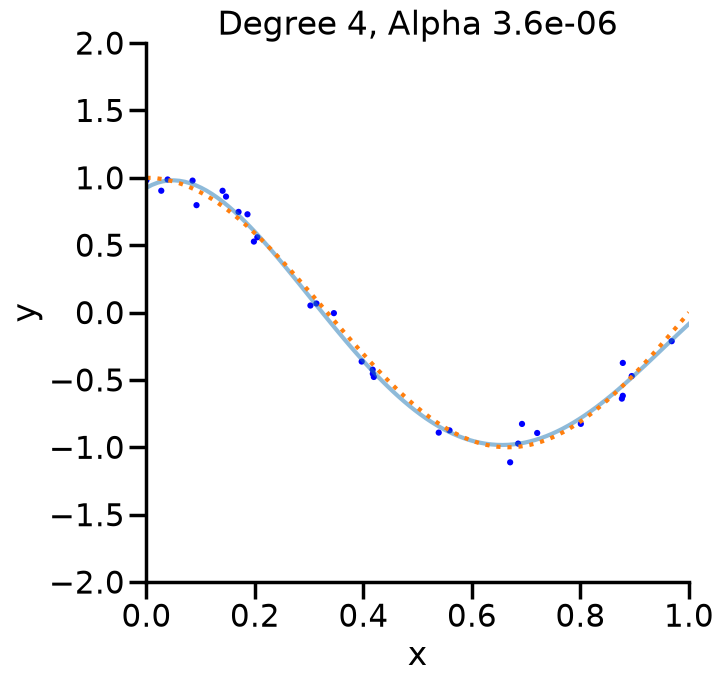

In [19]:
best_degree = grid_search.best_params_['polynomial_features__degree']
best_alpha = grid_search.best_params_['linear_regression__alpha']
X_plot = X_plot[:,np.newaxis]
plt.figure(figsize=(7, 7))
plt.plot(X_plot, grid_search.predict(X_plot),'-',label="Model",alpha=0.5)
plt.plot(X_plot, true_fun(X_plot), ':',label="True function",alpha=1)
plt.scatter(X_cos, y_cos, c='Blue', s=20, edgecolors='none')
plt.xlabel("x")
plt.ylabel("y")
plt.xlim((0, 1))
plt.ylim((-2, 2))
sns.despine()
plt.title("Degree {}, Alpha {:.1e}".format(best_degree,best_alpha))
plt.show()

## Randomized Search

In reality, grid search is wasteful and not easy to control. A better (and still easy way) is to randomize the search. To do this, we will need to tell the model how to sample randomly in the hyper-parameter space:

In [20]:
# Now, instead of specifying exact which points to test, we instead
# have to specify a distribution to sample from.
# For example, things from http://docs.scipy.org/doc/scipy/reference/stats.html
from scipy.stats import randint as sp_randint
from scipy.stats import lognorm as sp_lognorm

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
parameters = {'polynomial_features__degree': sp_randint(1,20), # We want an integer
              'linear_regression__alpha': sp_lognorm(1),
              'polynomial_features__include_bias':[True, False]} # Selecting from two is fine

Need something whose logarithmic distribution we can control -- *e.g.*, something on the positive reals? How about a lognormal?
$$
\mathcal{N}(\ln x;\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left[-\frac {(\ln x - \mu)^2} {2\sigma^2}\right].
$$

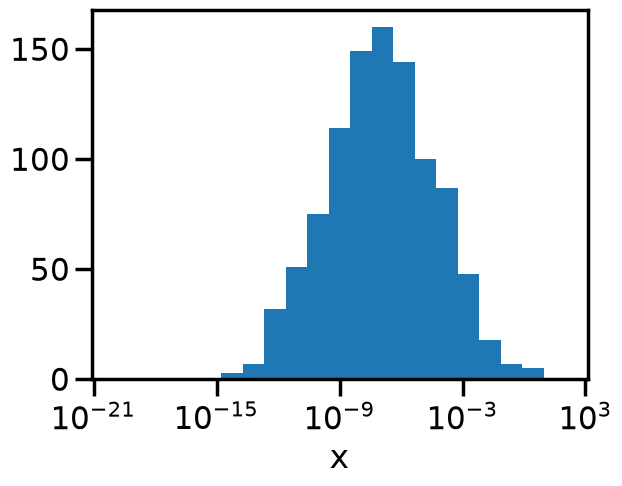

In [21]:
sigma=6
rv = sp_lognorm(sigma,scale=1e-7)

plt.figure()
plt.hist(rv.rvs(size=1000),bins=np.logspace(-20, 2, 22))
plt.xscale('log')
plt.xlabel('x')
plt.show()

In [22]:
parameters = {'polynomial_features__degree': sp_randint(1,20), # We want an integer
              'linear_regression__alpha': sp_lognorm(sigma,scale=1e-7),
              'polynomial_features__include_bias':[True, False]} # Selecting from two is fine

In [23]:
# Fitting the high degree polynomial makes the linear system almost
# singular, which makes Numpy issue a Runtime warning.
# This is not a problem here, except that it pops up the warning box
# So I will disable it just for pedagogical purposes
import warnings
warnings.simplefilter('ignore',RuntimeWarning)

# specify parameters and distributions to sample from
from sklearn.model_selection import RandomizedSearchCV

# run randomized search
#n_iter_search = 300 # How many random parameter settings should we try?
n_iter_search = len(grid_search.cv_results_['params']) # Give it same # as grid search, to be fair
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=parameters,
                                   n_iter=n_iter_search, 
                                   cv=shuffle_cv, # How do you want to cross-validate?
                                   scoring = 'neg_mean_squared_error')
random_search.fit(X_cos, y_cos)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...4(10000.0)))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'linear_regression__alpha': <scipy.stats....001DA1FBB69D0>, 'polynomial_features__degree': <scipy.stats....001DA1FAF0350>, 'polynomial_features__include_bias': [True, False]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",300
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",ShuffleSplit(...ain_size=None)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter t

In [24]:
random_search.best_params_ # Once finished, you can see what the best parameters are

{'linear_regression__alpha': np.float64(2.3284176681278128e-06),
 'polynomial_features__degree': 4,
 'polynomial_features__include_bias': True}

In [25]:
print("Best MSE for Random Search: {:.2e}".format(-random_search.best_score_))

Best MSE for Random Search: 7.00e-03


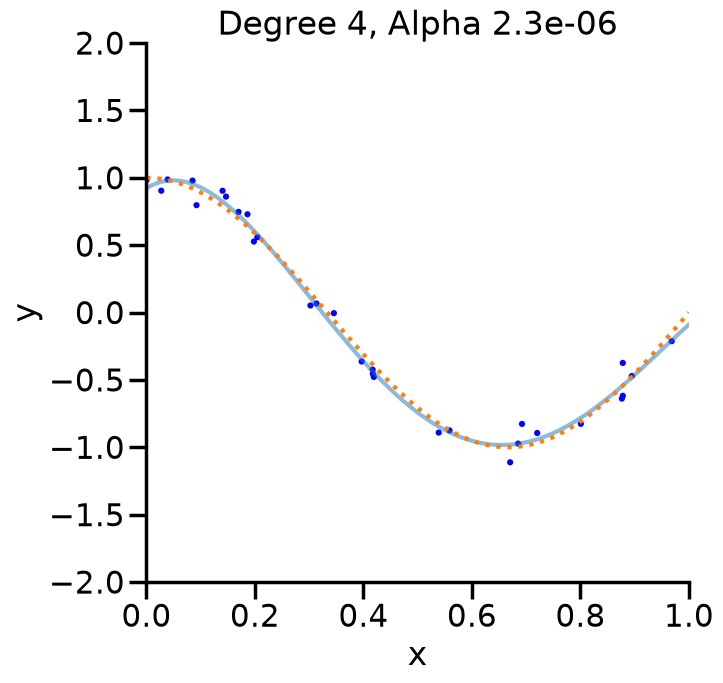

In [26]:
best_degree = random_search.best_params_['polynomial_features__degree']
best_alpha = random_search.best_params_['linear_regression__alpha']

plt.figure(figsize=(7, 7))
plt.plot(X_plot, random_search.predict(X_plot),'-',label="Model",alpha=0.5)
plt.plot(X_plot, true_fun(X_plot), ':',label="True function",alpha=1)
plt.scatter(X_cos, y_cos, c='Blue', s=20, edgecolors='none')
plt.xlabel("x")
plt.ylabel("y")
plt.xlim((0, 1))
plt.ylim((-2, 2))
sns.despine()
plt.title("Degree {}, Alpha {:.1e}".format(best_degree,best_alpha))
plt.show()

## Global Bayesian Optimization

Surely, since we are essentially doing optimization, we could approach hyper-parameter selection as an optimization problem as well, right?

Enter techniques like Global Bayesian Optimization below:

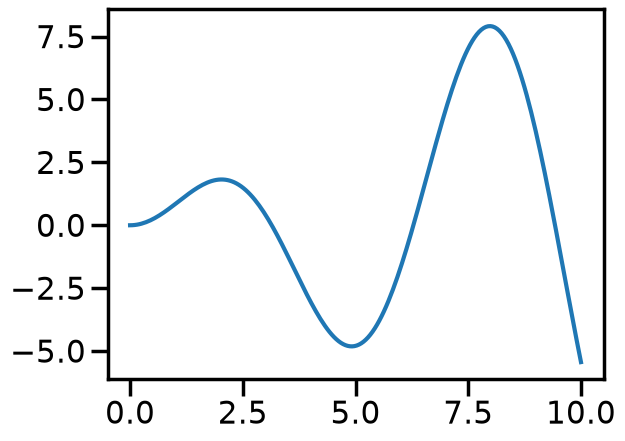

In [27]:
def f(x):
    """The function to predict."""
    return x * np.sin(x)
    # Try others!
    #return 5 * np.sinc(x)
    #return x
    
X_bo = np.atleast_2d(np.linspace(0, 10, 200)).T

# Observations
y_bo = f(X_bo).ravel()

plt.figure()
plt.plot(X_bo, y_bo)
plt.show()

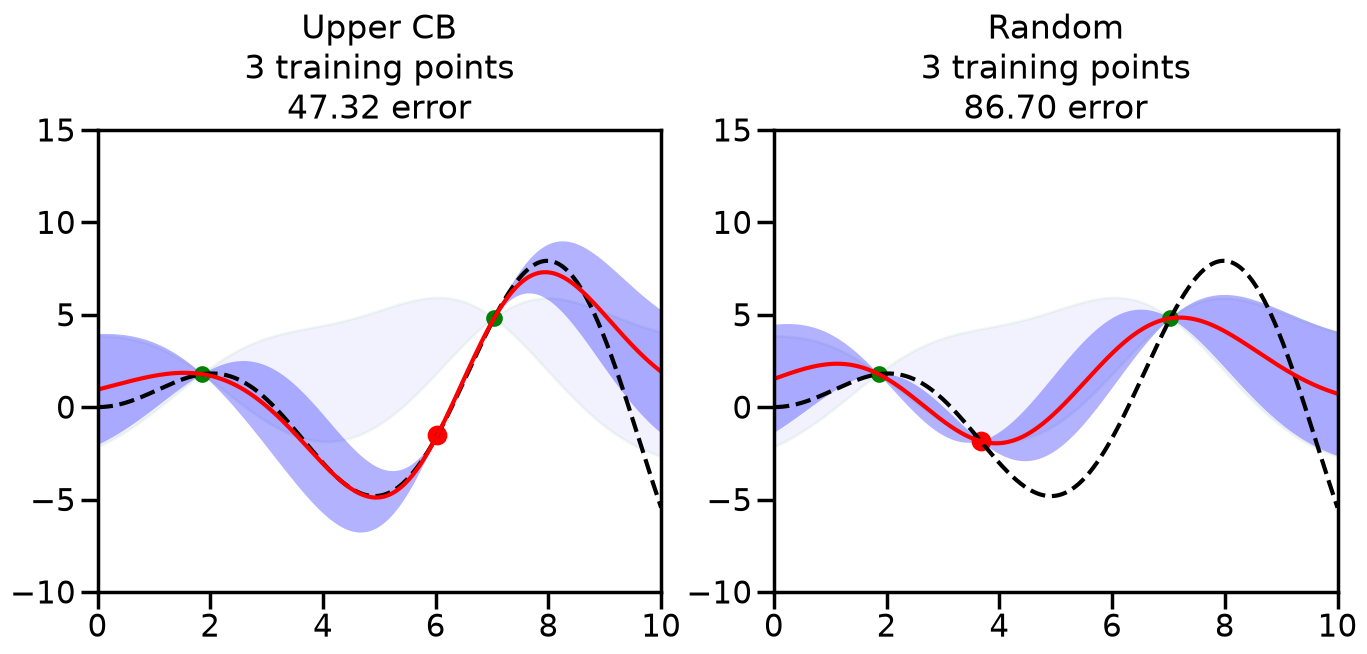

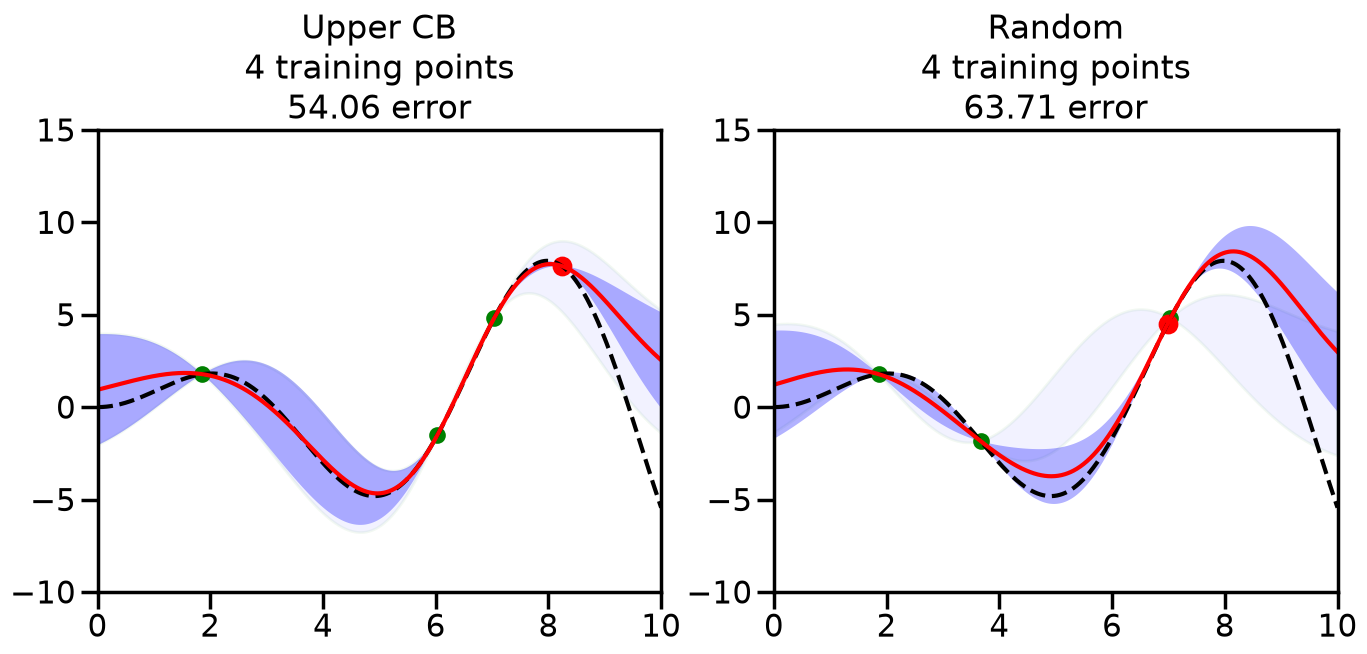

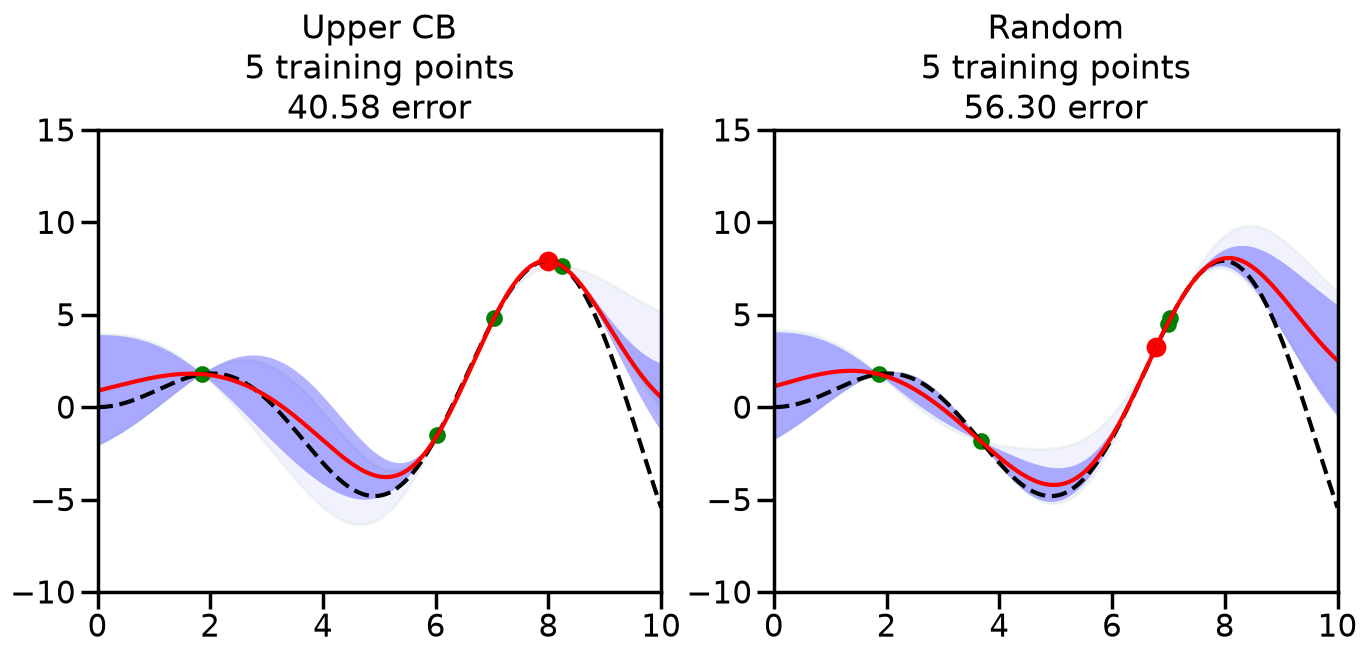

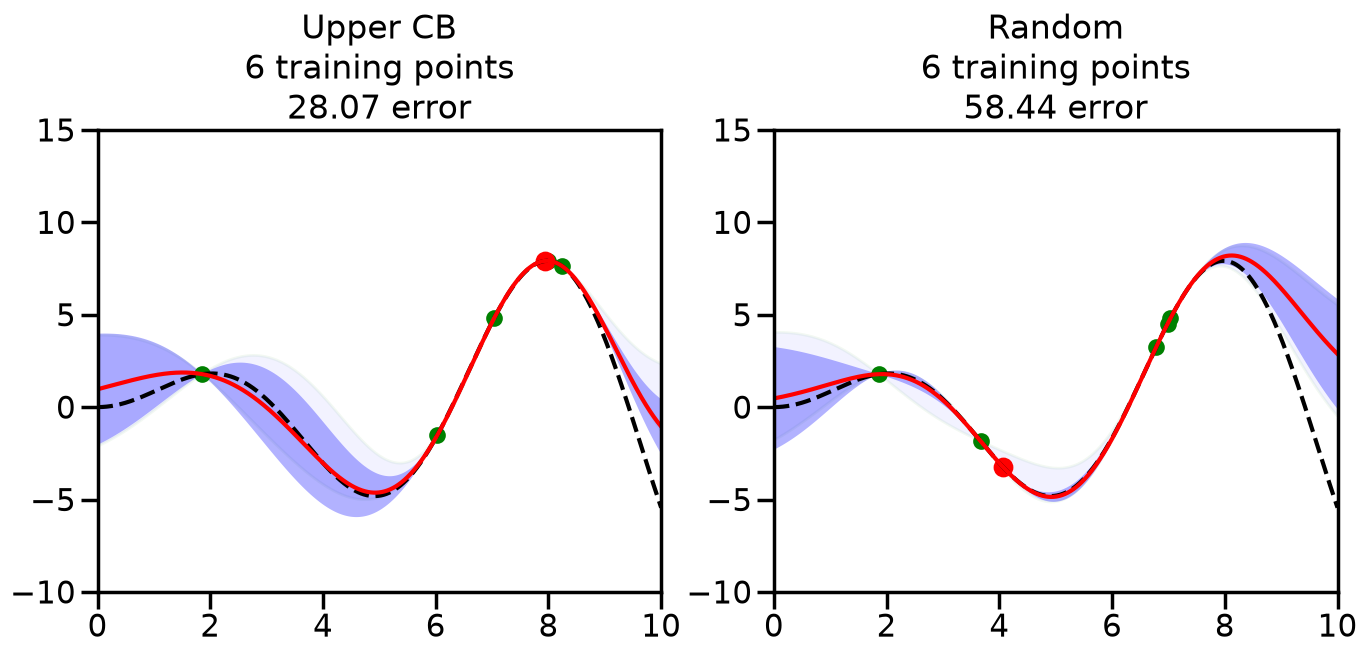

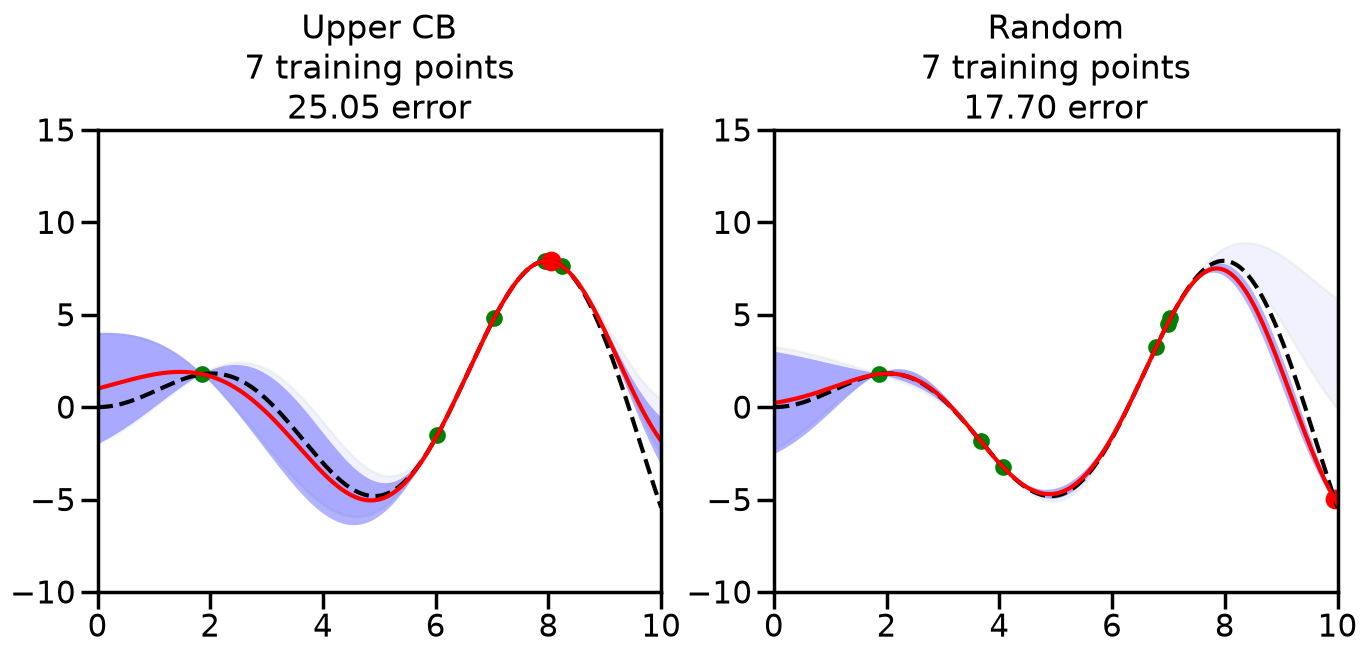

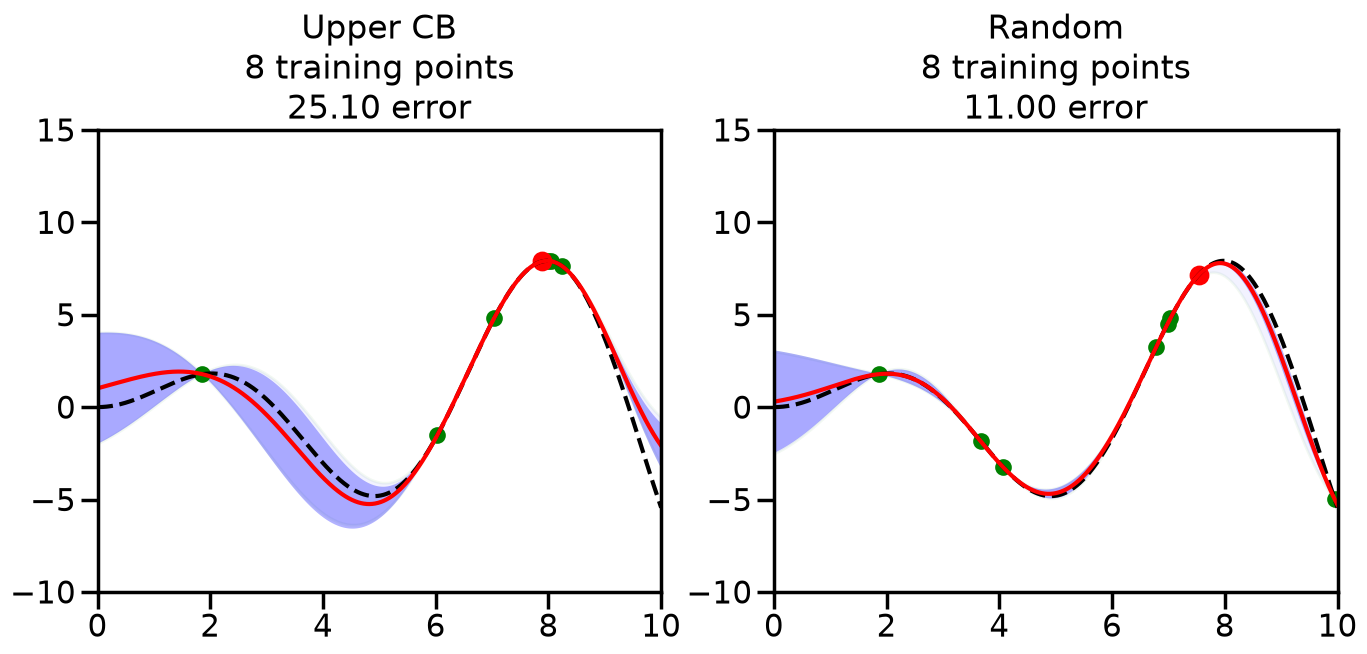

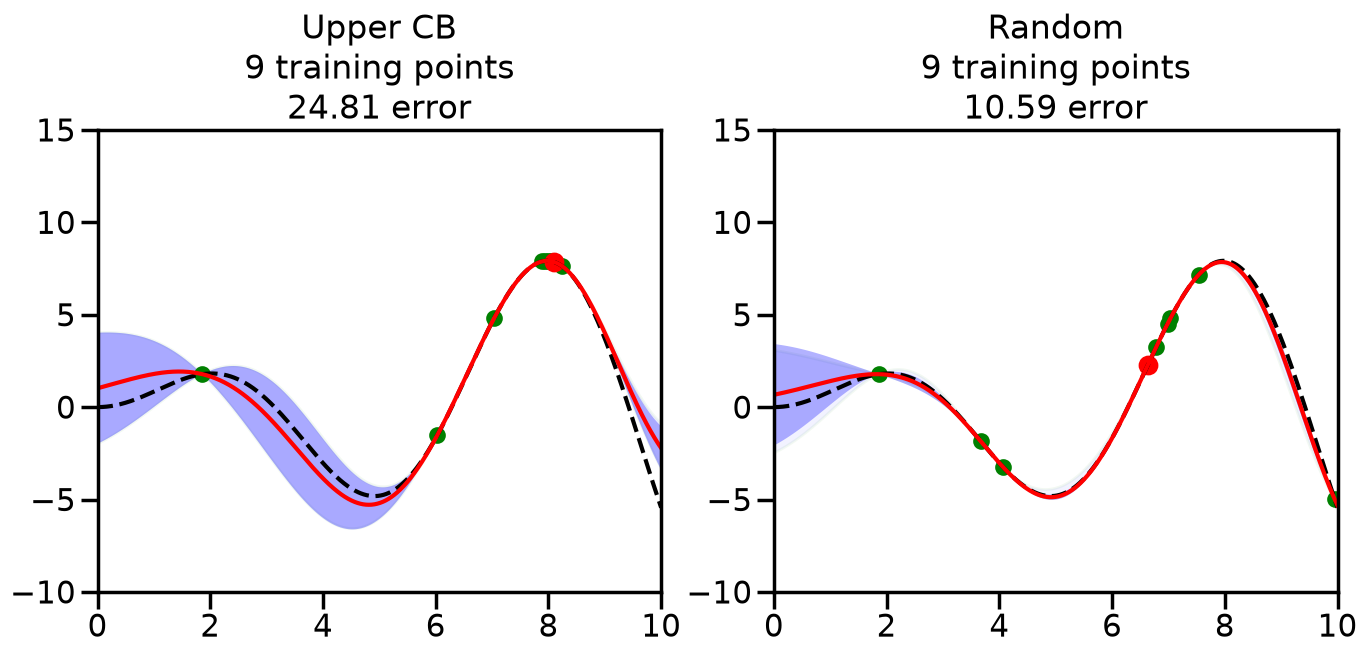

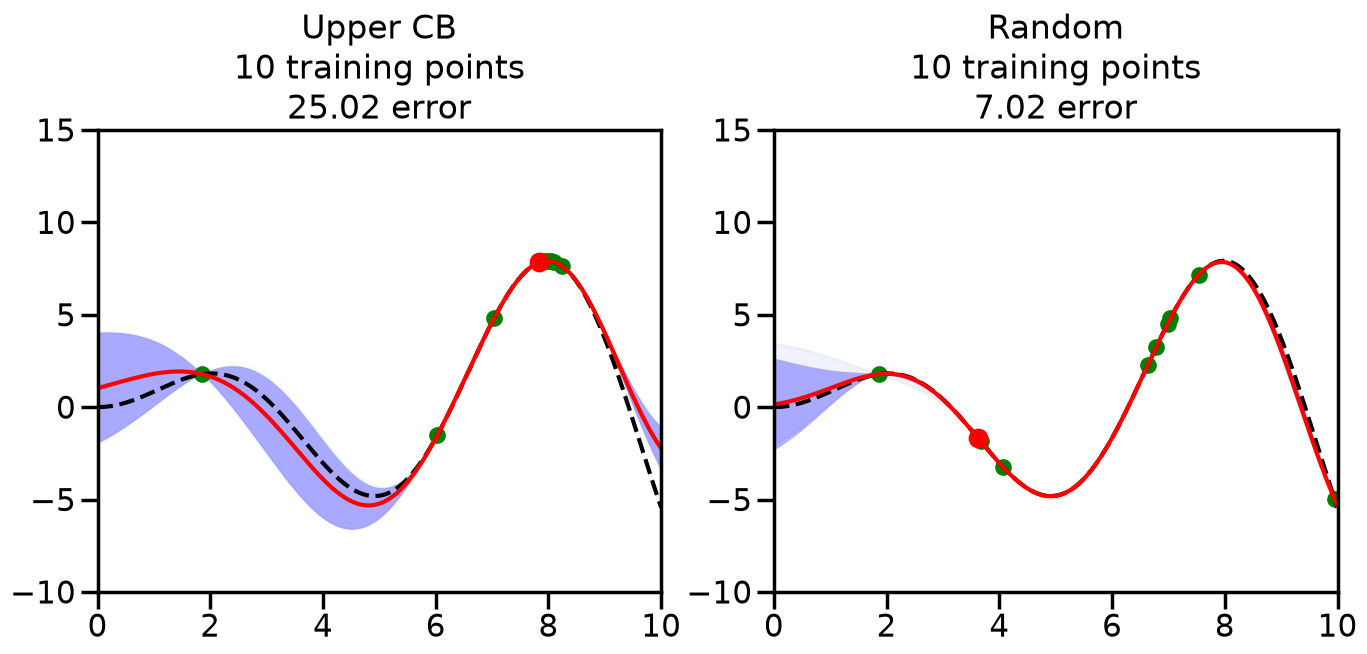

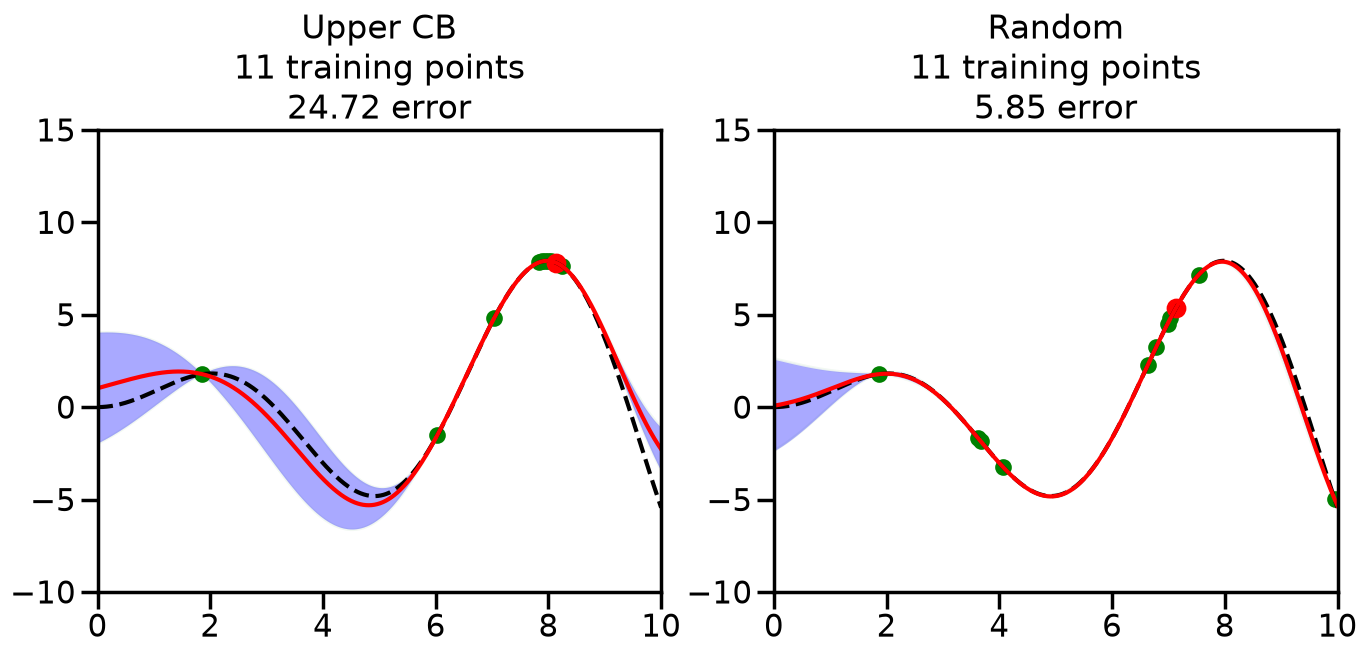

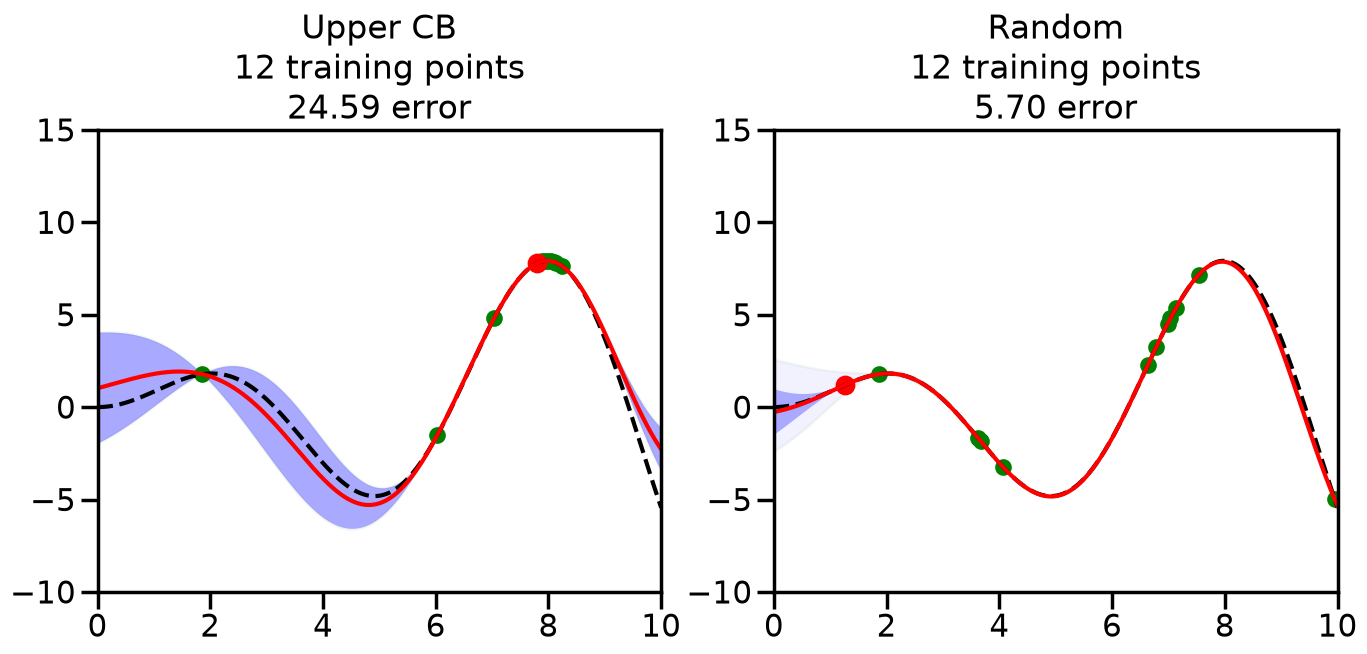

In [28]:
########################################################
# This is just a helper function, no need to worry about
# The internals.
# We will return to this example in Week 14
########################################################
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

np.random.seed(1)

# Mesh the input space for evaluations of the real function, the prediction and
# its MSE
x = np.atleast_2d(np.linspace(0, 10, 1000)).T

# Create a Gaussian Process model
#kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
#gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
kernel = C(3.0)*RBF(1.5)
gp = GaussianProcessRegressor(kernel=kernel,alpha=1e-6,optimizer=None)
#gp = GaussianProcess(corr='cubic', theta0=1e-2, thetaL=1e-4, thetaU=1e-1,random_start=100)

# Now, ready to begin learning:
train_ind ={
    'Upper CB':   np.zeros(len(X_bo),dtype=bool),
    'Random':np.zeros(len(X_bo),dtype=bool)
}
options = train_ind.keys()

possible_points = np.array(list(range(len(X_bo))))
# Possible Initialization options
# 1. Select different points randomly
#for i in range(2):
#    for o in options:
#        ind = np.random.choice(possible_points[~train_ind[o]],1)
#        train_ind[o][ind] = True

# 2. Start with end-points
#for o in options:
#    train_ind[o][0] = True
#    train_ind[o][-1] = True

# 3. Start with same random points
for ind in np.random.choice(possible_points,2):
    for o in options:
        train_ind[o][ind] = True

plot_list = np.array([5,10,20,30,40,50,len(X_bo)])
for i in range(10):
    # As i increases, we increase the number of points
    plt.figure(figsize=(16,6))
    for j,o in enumerate(options):
        plt.subplot(1,2,j+1)
        gp.fit(X_bo[train_ind[o],:],y_bo[train_ind[o]])
        yp,sigma = gp.predict(X_bo[~train_ind[o],:], return_std=True)
        ucb = yp + 1.96*sigma
        if o == 'Upper CB':
            #candidates = np.extract(MSE == np.amax(MSE),X_bo[~train_ind[o],:])
            candidates = np.extract(ucb == np.amax(ucb),X_bo[~train_ind[o],:])
            next_point = np.random.choice(candidates.flatten())
            next_ind = np.argwhere(X_bo.flatten() == next_point)
        elif o == 'Random':
            next_ind = np.random.choice(possible_points[~train_ind[o]],1)
        train_ind[o][next_ind] = True
        
        # Plot intermediate results
        yp,sigma = gp.predict(x, return_std=True)
        plt.fill(np.concatenate([x, x[::-1]]),
                np.concatenate([yp - 1.9600 * sigma,
                               (yp + 1.9600 * sigma)[::-1]]),'b',
                alpha=0.05,  ec='g', label='95% confidence interval')
    
        n_train = np.count_nonzero(train_ind[o])

        gp.fit(X_bo[train_ind[o],:],y_bo[train_ind[o]])
        # Show progress
        yp,sigma = gp.predict(x, return_std=True)
        yt = f(x)
        error = np.linalg.norm(yp-yt.flatten())

        plt.fill(np.concatenate([x, x[::-1]]),
                np.concatenate([yp - 1.9600 * sigma,
                               (yp + 1.9600 * sigma)[::-1]]),'b',
                alpha=0.3,  ec='None', label='95% confidence interval')
        
        plt.plot(x,yt,'k--',alpha=1)
        plt.plot(x,yp,'r-',alpha=1)
        plt.scatter(X_bo[train_ind[o],:],y_bo[train_ind[o]],color='g',s=100)
        plt.scatter(X_bo[next_ind,:].flatten(),y_bo[next_ind].flatten(),color='r',s=150)
        plt.ylim([-10,15])
        plt.xlim([0,10])
        plt.title("%s\n%d training points\n%.2f error"%(o,n_train,error))
    plt.show()

## The Curse of Dimensionality

While the above approaches seem to work well on the small examples we showed, in practice, as the number of hyper-parameters increases we run into (sometimes exponentially) larger problems related to something called the "Curse of Dimensionality." To get a rough sense of how this works and why it makes search (and especially sampling) difficult, let's look at one example, which is the ratio between the volume of a sphere with diameter 1 and the volume of a cube with sides length 1. That is, you are essentially fitting a hyper-sphere exactly inside of a hyper-cube and then asking how their volumes compare. We will compute their ratio as N (the number of dimensions) increases:

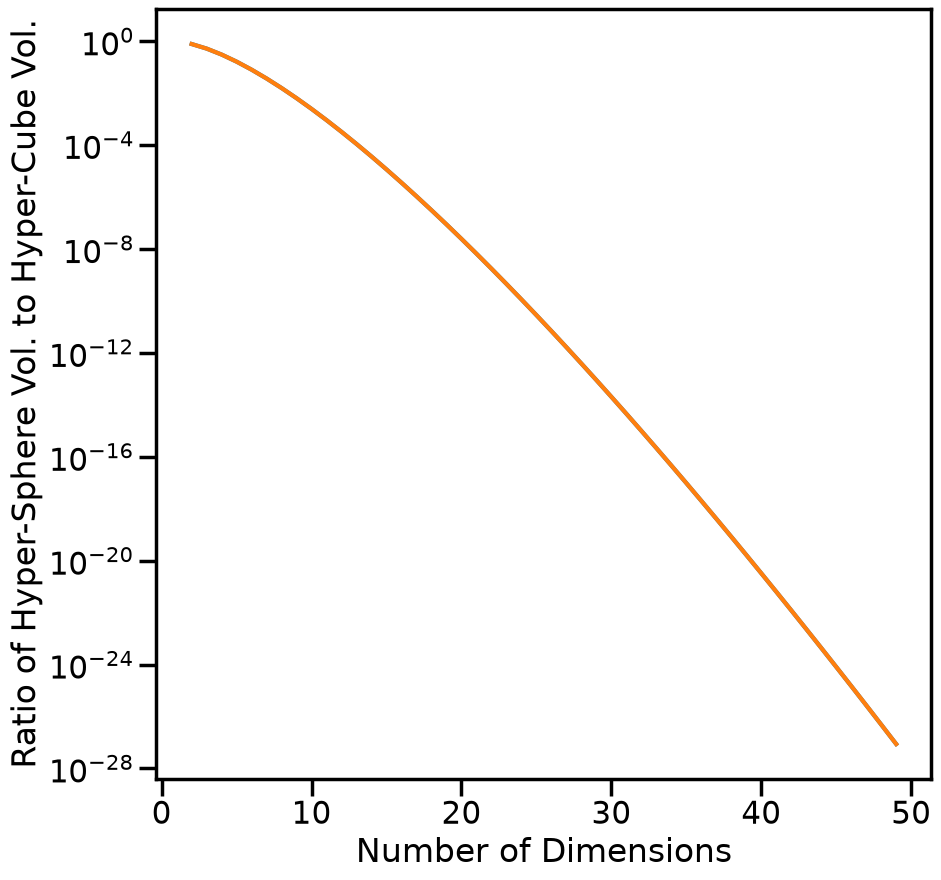

In [29]:
from math import gamma
V_sphere = lambda d: np.pi**(d/2.0)
V_cube = lambda d: d*2**(d-1)*gamma(d/2.0)
volume_ratio = lambda d: V_sphere(d)/V_cube(d)

d = range(2,50)
ratio = [volume_ratio(i) for i in d]
plt.figure(figsize=(10,10))
plt.plot(d,ratio)
plt.semilogy(d,ratio)
plt.ylabel("Ratio of Hyper-Sphere Vol. to Hyper-Cube Vol.")
plt.xlabel("Number of Dimensions")
plt.show()


What we can see in the above is that as N increases most of the volume of the space is actually contained in the **corners** of the hypercube, and thus if we try to sample uniformly in the hyper-volume (or have Bayesian Optimization sample points where it is uncertain), then most of the samples will end up being outside of the main "sphere" at the center of our hyperparameter space. You can see similar effects of other properties such as:

* The distance ratio between min and max distances among points randomly sampled in the space.
* How this affects which points are "near" or "far" from a given point (it won't change the relative ordering, but the comparative distances will get compressed such that every point looks far away)
* The effect on how sampling points from a Gaussian Density function end up concentrating on "rings" within the hyper-parameter space (see below Exercise)

All of these effects point toward being careful how you interpret space filling strategies when the number of dimensions in the space becomes large.

## Exercises

The exercises reuse the data and code from this chapter, so run the chapter's cells first. Rough time estimates are in the titles; the last one is meant as a longer take-home task. Worked solutions are in the Exercise Solutions appendix.

::: {.callout-note appearance="simple" icon=false}
### Exercise 1 (~5 min): Which split would you use?
For each situation, name the cross-validation strategy you would use (shuffled K-fold, stratified K-fold, group K-fold, or a time series split), say what you would group or stratify on if anything, and describe what data might leak if you just used a plain shuffled split.

- (a) A strain gauge on a bridge has logged one reading per minute for a year; you want to predict the reading one hour ahead.
- (b) Six turbine blades were each laser-scanned 30 times; the model should predict the surface roughness of blades that have not been scanned yet.
- (c) Weld inspection images, of which 2 percent show a defect, and you want to train a model to classify defective versus sound welds based on the images.
- (d) Forty tensile specimens, each cast and tested independently, and you wish to build a model to predict the yield stress of that specimen.
- (e) You buy four different weld inspection imaging machines and deploy each at four production plants, then build a model that can predict their inspection accuracy based on data you collect in production. You wish to estimate how a newly purchased inspection machine might do at a fifth plant, were you to buy another.
- (f) Twenty battery cells have been cycled for months, and you want to forecast the remaining life of *these same cells* from their history so far.
:::

---

::: {.callout-note appearance="simple" icon=false}
### Exercise 2 (~3 min): Read the validation curve
Go back to the one-dimensional sweep over $\alpha$ for the 15-degree polynomial (the cell that produced `alphas_1d` and `scores_1d`) and to the two-dimensional map over degree and $\alpha$.

- (a) Read off, or compute with `np.argmin`, the value of $\alpha$ with the lowest cross-validated MSE in the 1D sweep.
- (b) The curve is U-shaped. Explain what goes wrong at the right end (large $\alpha$) and at the left end (tiny $\alpha$), using the words *bias* and *variance*.
- (c) Look closely at the left half of the curve. Between about $10^{-9}$ and $10^{-3}$ it is nearly flat, yet below $10^{-9}$ it shoots up by two orders of magnitude. Why does a penalty as tiny as $10^{-9}$ make such a large difference, and why does nothing much change over the next six decades? (Think about the size of the unregularized coefficients of a 15-degree polynomial on $[0, 1]$, which you saw in the previous chapter.)
:::

---


::: {.callout-note appearance="simple" icon=false}
### Exercise 3 (~3 min): Count the fits
Suppose each model fit in the grid search were not a polynomial but a 30-second finite-element simulation.

- (a) From the `parameters` dictionary of the grid search (15 degrees, 10 values of $\alpha$, 2 options for `include_bias`) and the `shuffle_cv` object (20 splits), how many fits does `GridSearchCV` perform, and how long would that take? Check your count against `len(grid_search.cv_results_['params'])`.
- (b) How many fits did the randomized search use, and why did the chapter choose that number?
- (c) If you could afford only 60 fits in total, how would you split them between hyperparameter settings and cross-validation folds? What do you give up or gain when you trade samples between those two categories?
:::

---

::: {.callout-note appearance="simple" icon=false}
### Exercise 4 (~6 min): Pick the sampling distribution
Randomized search needs a probability distribution for every hyperparameter. For each parameter below, propose a distribution from `scipy.stats` (or a list to choose from), give its support, and justify the choice in one sentence. Then implement one of them as an entry in a `param_distributions` dictionary and plot a histogram of 1000 draws to check that it looks the way you intended (the chapter did this for the lognormal).

- (a) The ridge penalty $\alpha$, plausible anywhere between $10^{-8}$ and $10^{3}$.
- (b) The polynomial degree, an integer between 1 and 20.
- (c) The fraction of the training data used in each bootstrap subsample, anywhere in $(0, 1)$.
- (d) The number of hidden units in a neural network layer, between 8 and 1024.
- (e) The phase angle of a sinusoidal feature, anywhere in $(-\pi, \pi]$.

Which of these would be badly served by a plain uniform distribution, and what would go wrong?
:::

In [35]:
# You can use this code cell for this exercise, if you like.


---


Run the cell below to produce the figure for Exercise 5. It fits the chapter's Gaussian process to five observations of $f(x) = x \sin x$ and marks four candidate locations for the next evaluation.

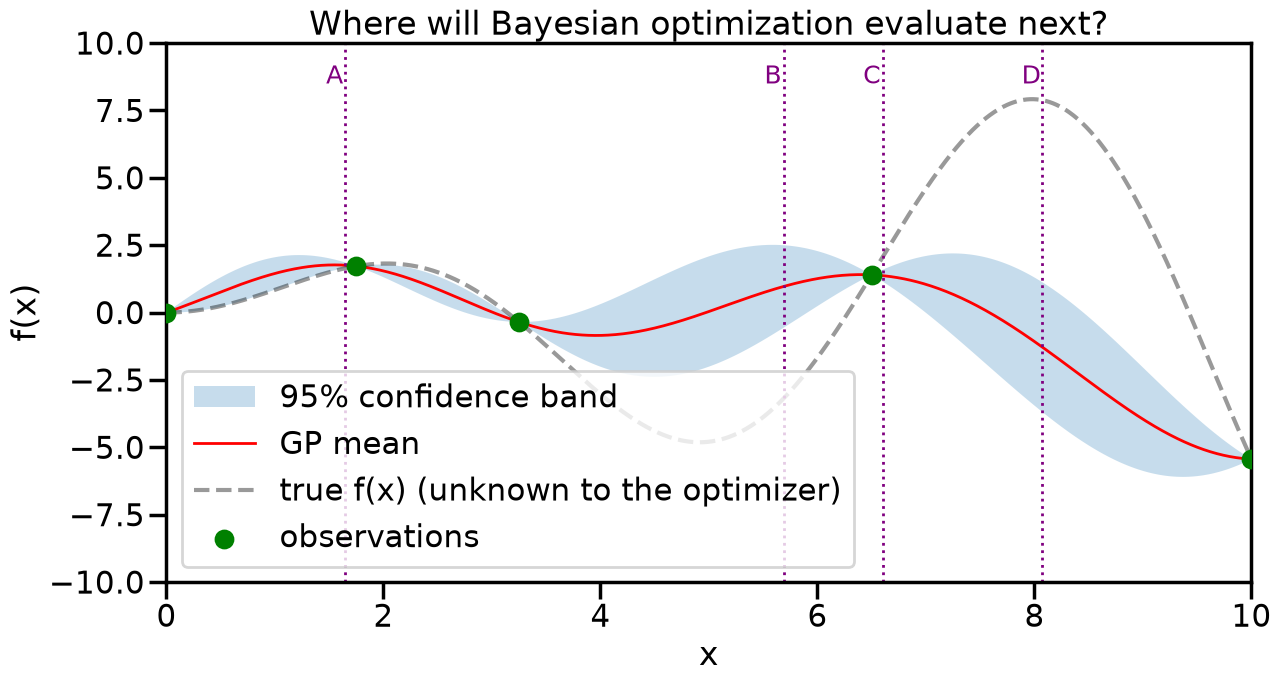

In [38]:
#| echo: false
# Exercise 5 figure: GP posterior after five observations, with four candidate next points.
ex6_observed_x = np.array([0.0, 1.75, 3.25, 6.5, 10.0])
ex6_observed_y = f(ex6_observed_x)
ex6_gp = GaussianProcessRegressor(kernel=C(3.0) * RBF(1.5), alpha=1e-6, optimizer=None)
ex6_gp.fit(ex6_observed_x[:, np.newaxis], ex6_observed_y)

ex6_grid = np.linspace(0, 10, 1001)
ex6_mean, ex6_std = ex6_gp.predict(ex6_grid[:, np.newaxis], return_std=True)

# Candidate positions: the exploit pick, the UCB pick, the exploration pick, and one observed point
ex6_candidate_x = np.array([
    ex6_grid[np.argmax(ex6_mean)],                    # highest posterior mean
    ex6_grid[np.argmax(ex6_mean + 1.96 * ex6_std)],   # highest upper confidence bound
    ex6_grid[np.argmax(ex6_mean + 10.0 * ex6_std)],   # highest uncertainty (in effect)
    6.5,                                              # an already observed point
])
ex6_candidate_x = np.sort(ex6_candidate_x)           # letters A to D run left to right

plt.figure(figsize=(14, 7))
plt.fill_between(ex6_grid, ex6_mean - 1.96 * ex6_std, ex6_mean + 1.96 * ex6_std, alpha=0.25,
                 label="95% confidence band")
plt.plot(ex6_grid, ex6_mean, 'r-', lw=2, label="GP mean")
plt.plot(ex6_grid, f(ex6_grid), 'k--', alpha=0.4, label="true f(x) (unknown to the optimizer)")
plt.scatter(ex6_observed_x, ex6_observed_y, color='g', s=150, zorder=5, label="observations")
for letter, cx in zip("ABCD", ex6_candidate_x):
    plt.axvline(cx+0.1, color='purple', linestyle=':', lw=2)
    plt.annotate(letter, (cx, 8.5), ha='center', color='purple', fontsize=18)
plt.ylim(-10, 10)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend(loc="lower left")
plt.title("Where will Bayesian optimization evaluate next?")
plt.show()

::: {.callout-note appearance="simple" icon=false}
### Exercise 5 (~5 min): Where does Bayesian optimization look next?
The figure shows the Gaussian process fit after five evaluations of an expensive function we want to *maximize*: the red line is the posterior mean, the shaded band is the 95 percent confidence region, and A to D are four candidate locations for the next evaluation. The chapter's acquisition function is the upper confidence bound, $\mathrm{UCB}(x) = \mu(x) + \kappa\,\sigma(x)$ with $\kappa = 1.96$.

- (a) Which candidate of the four letters would UCB pick? For each of the other three, say in one sentence why it will not pick that point.
- (b) Which candidate would a purely greedy strategy ($\kappa = 0$) pick? Which one would a very exploratory strategy ($\kappa = 10$) pick?
- (c) One of the candidates would never be picked by any $\kappa$. Which one, and why?
:::

---


The next exercise is about interpreting a figure rather than writing code. The cell below plots the probability density of the *distance from the origin* of a standard Gaussian in $n$ dimensions. (This is the chi distribution $p_R(r) = \frac{2\, r^{n-1}}{(2\sigma^2)^{n/2}\, \Gamma\!\left(\frac{n}{2}\right)} \exp\!\left( -\frac{r^2}{2\sigma^2} \right) = \frac{2\, r^{n-1}}{2^{n/2}\, \Gamma\!\left(\frac{n}{2}\right)} \exp\!\left( -\frac{r^2}{2} \right)$.) We also plot a histogram of that distance for random samples in $n = 10$ dimensions. Feel free to read the code if it helps you understand where the plots come from.

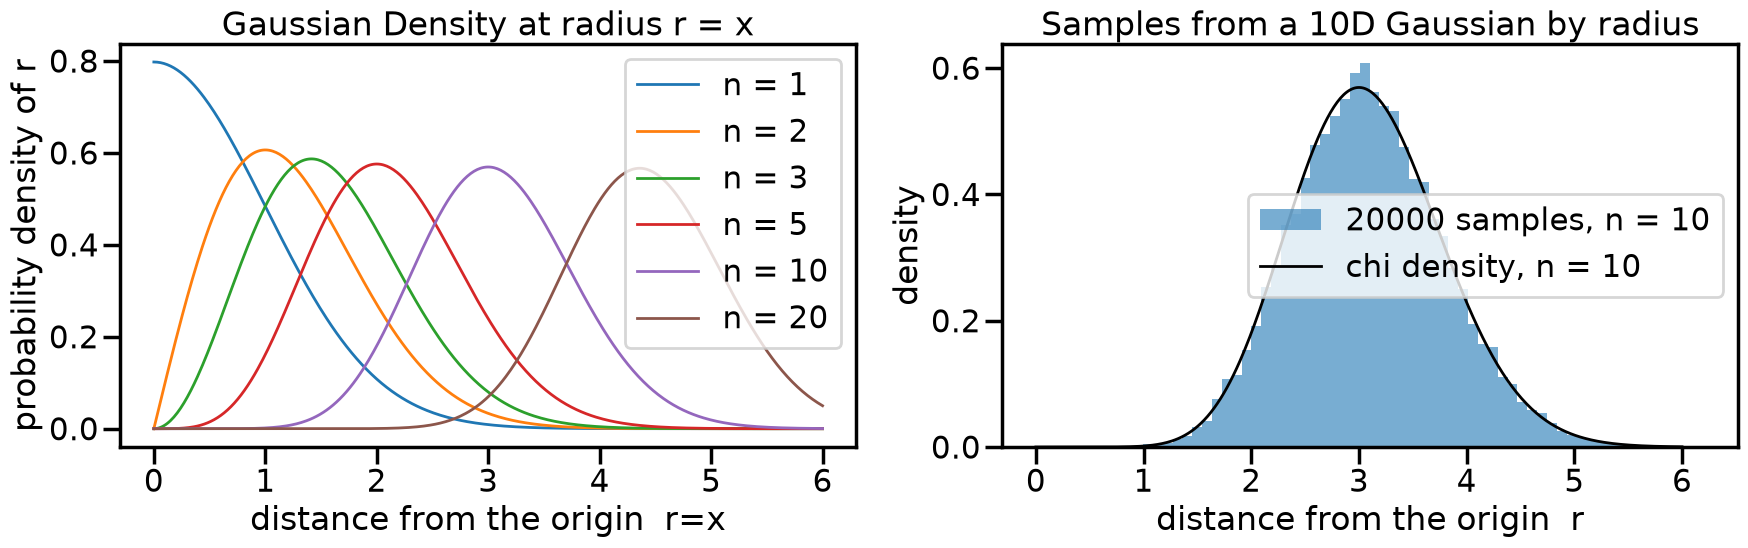

In [41]:
from scipy.stats import chi

radius = np.linspace(0, 6, 400)
dimensions = [1, 2, 3, 5, 10, 20]

fig, (ax_density, ax_hist) = plt.subplots(1, 2, figsize=(18, 6))
for n_dim in dimensions:
    # For a standard Gaussian in n dimensions the distance from the origin follows a chi distribution
    ax_density.plot(radius, chi.pdf(radius, df=n_dim), lw=2, label=f"n = {n_dim}")
ax_density.set_xlabel("distance from the origin  r=x")
ax_density.set_ylabel("probability density of r")
ax_density.set_title("Gaussian Density at radius r = x")
ax_density.legend()

gaussian_rng = np.random.default_rng(0)
samples_10d = gaussian_rng.normal(size=(20000, 10))
ax_hist.hist(np.linalg.norm(samples_10d, axis=1), bins=60, density=True, alpha=0.6, label="20000 samples, n = 10")
ax_hist.plot(radius, chi.pdf(radius, df=10), 'k-', lw=2, label="chi density, n = 10")
ax_hist.set_xlabel("distance from the origin  r")
ax_hist.set_ylabel("density")
ax_hist.set_title("Samples from a 10D Gaussian by radius")
ax_hist.legend()
plt.tight_layout()
plt.show()

::: {.callout-note appearance="simple" icon=false}
### Exercise 6 (~5 min): A Gaussian is a donut
The density of a Gaussian is $p(\mathbf{x}) = \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{d/2} \lvert \boldsymbol{\Sigma} \rvert^{1/2}} \exp\!\left( -\frac{1}{2} (\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu}) \right)$. For a standard Gaussian this simplifies and is proportional to $p(\mathbf{x}) \propto e^{-\|\mathbf{x}\|^2/2}$. We see that the probability is largest at the origin in *every* dimension. Yet the figure says that in ten dimensions almost no sample lands anywhere near the origin.

- (a) Where is the peak of the radial density for $n = 1, 2, 3, 5, 10, 20$? Read the values off the plot and propose a formula in terms of $n$.
- (b) Roughly what fraction of the $n = 10$ samples fall inside the unit ball $r < 1$? And inside $r < 2$?
- (c) Resolve the apparent contradiction: how can the origin be the most probable *point* while the probability of being *near* the origin is almost zero? (Think about how much volume a thin shell at radius $r$ has in $n$ dimensions.)
- (d) Name one consequence for a method that relies on distances between points, and one for a method that draws random samples in a high-dimensional space.
:::

---


::: {.callout-note appearance="simple" icon=false}
### Exercise 7 (~10 min): Nearest and farthest neighbours
The chapter's volume-ratio plot shows one face of the curse of dimensionality. Here is another, which you will build yourself.

Sample $N = 500$ points uniformly in the unit cube $[0, 1]^d$. For every point, compute the distance to its *nearest* other point and to its *farthest* other point, and form the ratio $d_{\min} / d_{\max}$. Average the ratio over the 500 points. Repeat for $d \in \{1, 2, 5, 10, 20, 50, 100, 500, 1000\}$ with a fixed random seed and plot the mean ratio against $d$ on a logarithmic $d$-axis. (`scipy.spatial.distance.cdist` gives you all pairwise distances with one function, although remember to exclude each point's zero distance to itself.)

- (a) Describe the trend. What does the ratio approach as $d$ grows, and what does that mean in words about the nearest and the farthest neighbour?
- (b) What does this do to a $k$-nearest-neighbour method in high dimensions?
- (c) What does it imply for grid search and random search when the number of hyperparameters grows?
:::
